# Sección 9 — Enfoque B: $\mathcal{G}(p,c)$ cruzado por k-pairs

Implementa la fórmula definida en el MD 9:
$$\mathcal{G}(p,\,c) = \left(\bigcup_{k=1}^{4} \mathcal{G}_k(p,c)\right) \setminus \{\emptyset\}$$

El objetivo es recuperar el GUID correcto para cada uno de los **36 eventos centinela k=1**,
consultando los cuatro k-pairs en lugar de solo k=1 (Enfoque A).

## Setup

In [334]:
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 80)
pd.set_option('display.max_colwidth', 80)

NULL_GUID = '00000000-0000-0000-0000-000000000000'
DATA_DIR  = '../dataset/run-01-apt-1/'
print('OK')

OK


In [335]:
df = pd.read_csv(DATA_DIR + '02_sysmon-run-01.csv', low_memory=False)
df['_original_row_index'] = df.index
df['ts'] = pd.to_datetime(df['timestamp'].where(df['timestamp'] > 0), unit='ms')

viol = pd.read_csv(DATA_DIR + '04_sysmon-run-01-violations.csv', low_memory=False)
viol['ts'] = pd.to_datetime(viol['timestamp'].where(viol['timestamp'] > 0), unit='ms')

sentinel_k1 = (
    viol[~viol['EventID'].isin([8, 10]) & (viol['ProcessGuid'] == NULL_GUID)]
    .sort_values('_original_row_index')
    .reset_index(drop=True)
)

print(f'df          : {len(df):,} filas')
print(f'sentinel_k1 : {len(sentinel_k1)} eventos')

df          : 363,657 filas
sentinel_k1 : 36 eventos


---
## Tabla resumen: $\lvert\mathcal{G}(p,c)\rvert$ para los 36 eventos centinela k=1

Calculamos $\mathcal{G}(p,c)$ para cada uno de los 36 eventos y clasificamos
la acción de recuperación. Analizaremos los casos **evento por evento**,
comenzando por los de $\lvert\mathcal{G}\rvert = 1$ (regla `REPLACE_GUID` con
verificación temporal), luego los de $\lvert\mathcal{G}\rvert > 1$ (`REVIEW`),
y finalmente los de $\lvert\mathcal{G}\rvert = 0$ (`BOOT_ARTIFACT`) si los hubiera.

In [336]:
def compute_G(df, p, c):
    """Retorna G(p,c): conjunto de GUIDs reales observados para (p,c) en los 4 k-pairs."""
    g1 = set(df[~df['EventID'].isin([8,10]) & (df['Computer']==c) & (df['ProcessId']==p)
              ]['ProcessGuid'].dropna()) - {NULL_GUID}
    g2 = set(df[(df['EventID']==1) & (df['Computer']==c) & (df['ParentProcessId']==p)
              ]['ParentProcessGuid'].dropna()) - {NULL_GUID}
    g3 = set(df[df['EventID'].isin([8,10]) & (df['Computer']==c) & (df['SourceProcessId']==p)
              ]['SourceProcessGUID'].dropna()) - {NULL_GUID}
    g4 = set(df[df['EventID'].isin([8,10]) & (df['Computer']==c) & (df['TargetProcessId']==p)
              ]['TargetProcessGUID'].dropna()) - {NULL_GUID}
    return g1 | g2 | g3 | g4

rows = []
for i, row in sentinel_k1.iterrows():
    G = compute_G(df, row['ProcessId'], row['Computer'])
    card = len(G)
    accion = 'REPLACE_GUID*' if card == 1 else ('BOOT_ARTIFACT' if card == 0 else 'REVIEW')
    rows.append({
        'ev'      : i,
        'row_csv' : int(row['_original_row_index']),
        'EventID' : int(row['EventID']),
        'Computer': row['Computer'],
        'PID'     : int(row['ProcessId']),
        'Image'   : row['Image'],
        'ts'      : row['ts'],
        '|G|'     : card,
        'G'       : str(sorted(G)),
        'accion'  : accion,
    })

resumen = pd.DataFrame(rows)
print('Distribución de acciones (antes de verificación temporal):')
print(resumen['accion'].value_counts())
print()
resumen[['ev','row_csv','EventID','Computer','PID','Image','ts','|G|','accion']]

Distribución de acciones (antes de verificación temporal):
accion
REPLACE_GUID*    28
REVIEW            8
Name: count, dtype: int64



,ev,row_csv,EventID,Computer,PID,Image,ts,|G|,accion
0,0,5976,3,endofroad.boombox.local,3364,<unknown process>,2025-03-19 05:01:15.235,2,REVIEW
1,1,5977,3,endofroad.boombox.local,3364,<unknown process>,2025-03-19 05:01:15.237,2,REVIEW
2,2,5978,3,endofroad.boombox.local,3364,<unknown process>,2025-03-19 05:01:15.244,2,REVIEW
3,3,5979,3,endofroad.boombox.local,3364,<unknown process>,2025-03-19 05:01:15.247,2,REVIEW
4,4,19619,7,endofroad.boombox.local,2968,C:\Windows\System32\conhost.exe,2025-03-19 05:04:05.550,1,REPLACE_GUID*
5,5,22960,7,diskjockey.boombox.local,1972,C:\Windows\System32\taskhostw.exe,2025-03-19 05:04:29.691,1,REPLACE_GUID*
6,6,22961,7,diskjockey.boombox.local,1972,C:\Windows\System32\taskhostw.exe,2025-03-19 05:04:29.691,1,REPLACE_GUID*
7,7,22962,7,diskjockey.boombox.local,1972,C:\Windows\System32\taskhostw.exe,2025-03-19 05:04:29.691,1,REPLACE_GUID*
8,8,22963,7,diskjockey.boombox.local,1972,C:\Windows\System32\taskhostw.exe,2025-03-19 05:04:29.691,1,REPLACE_GUID*
9,9,22964,7,diskjockey.boombox.local,1972,C:\Windows\System32\taskhostw.exe,2025-03-19 05:04:29.691,1,REPLACE_GUID*


---
## Caso $\lvert\mathcal{G}\rvert = 1$ — Evento 04

**PID 2968 · `endofroad.boombox.local` · fila 19619**  
`C:\Windows\System32\conhost.exe`

Primer evento centinela k=1 con exactamente un GUID real observado.
Aplicamos la regla completa incluyendo la verificación temporal:

$$
\text{acción}(e^*, g_0) =
\begin{cases}
\texttt{REPLACE\_GUID} & \text{si } t_{\min}(g_0) \leq t^* \leq t_{\max}(g_0) \\
\texttt{REVIEW}        & \text{si } t^* > t_{\max}(g_0)
\end{cases}
$$

In [337]:
# Evento centinela e*
ev04 = sentinel_k1.iloc[4]
t_star = ev04['ts']
p04    = ev04['ProcessId']
c04    = ev04['Computer']

print('=== Evento centinela e* ===')
print(ev04[['_original_row_index','EventID','Computer','ProcessId','Image','ts']].to_string())

# G(p, c)
G04 = compute_G(df, p04, c04)
g0  = list(G04)[0]
print(f'\nG({int(p04)}, {c04}) = {{{g0}}}')
print(f'|G| = {len(G04)}  →  candidato único: {g0}')

=== Evento centinela e* ===
_original_row_index                              19619
EventID                                              7
Computer                       endofroad.boombox.local
ProcessId                                       2968.0
Image                  C:\Windows\System32\conhost.exe
ts                          2025-03-19 05:04:05.550000

G(2968, endofroad.boombox.local) = {44d66c27-5045-67da-3600-000000007100}
|G| = 1  →  candidato único: 44d66c27-5045-67da-3600-000000007100


In [338]:
# Ciclo de vida de g0: todos los eventos del CSV donde g0 aparece en cualquier k-pair
k1 = df[df['ProcessGuid']       == g0][['ts','EventID','ProcessId','Image','Computer']].assign(kpair='k1')
k2 = df[df['ParentProcessGuid'] == g0][['ts','EventID','ProcessId','Image','Computer']].assign(kpair='k2')
k3 = df[df['SourceProcessGUID'] == g0][['ts','EventID','ProcessId','Image','Computer']].assign(kpair='k3') if 'SourceProcessGUID' in df.columns else pd.DataFrame()
k4 = df[df['TargetProcessGUID'] == g0][['ts','EventID','ProcessId','Image','Computer']].assign(kpair='k4') if 'TargetProcessGUID' in df.columns else pd.DataFrame()

import pandas as pd
g0_events = pd.concat([k1, k2, k3, k4]).dropna(subset=['ts']).sort_values('ts')

print(f'Eventos de g0 por k-pair:')
print(g0_events['kpair'].value_counts().sort_index())
print()

t_min_g0 = g0_events['ts'].min()
t_max_g0 = g0_events['ts'].max()

print(f't_min(g0) = {t_min_g0}')
print(f't*        = {t_star}')
print(f't_max(g0) = {t_max_g0}')
print()

dentro = t_min_g0 <= t_star <= t_max_g0
accion = 'REPLACE_GUID' if dentro else 'REVIEW (t* fuera del ciclo de vida de g0)'
print(f't_min <= t* <= t_max : {dentro}')
print(f'Acción final         : {accion}')
print()
print(f'Total eventos de g0  : {len(g0_events)}  |  span = {(t_max_g0 - t_min_g0).total_seconds()*1000:.0f} ms')
g0_events.drop(columns='kpair')

Eventos de g0 por k-pair:
kpair
k1    30
Name: count, dtype: int64

t_min(g0) = 2025-03-19 05:04:05.552000
t*        = 2025-03-19 05:04:05.550000
t_max(g0) = 2025-03-19 05:04:06.014000

t_min <= t* <= t_max : False
Acción final         : REVIEW (t* fuera del ciclo de vida de g0)

Total eventos de g0  : 30  |  span = 462 ms


,ts,EventID,ProcessId,Image,Computer
19638,2025-03-19 05:04:05.552,1,2968.0,C:\Windows\System32\conhost.exe,endofroad.boombox.local
19639,2025-03-19 05:04:05.639,7,2968.0,C:\Windows\System32\conhost.exe,endofroad.boombox.local
19641,2025-03-19 05:04:05.639,7,2968.0,C:\Windows\System32\conhost.exe,endofroad.boombox.local
19642,2025-03-19 05:04:05.639,7,2968.0,C:\Windows\System32\conhost.exe,endofroad.boombox.local
19643,2025-03-19 05:04:05.639,7,2968.0,C:\Windows\System32\conhost.exe,endofroad.boombox.local
19644,2025-03-19 05:04:05.639,7,2968.0,C:\Windows\System32\conhost.exe,endofroad.boombox.local
19645,2025-03-19 05:04:05.639,7,2968.0,C:\Windows\System32\conhost.exe,endofroad.boombox.local
19648,2025-03-19 05:04:05.639,7,2968.0,C:\Windows\System32\conhost.exe,endofroad.boombox.local
19649,2025-03-19 05:04:05.639,7,2968.0,C:\Windows\System32\conhost.exe,endofroad.boombox.local
19651,2025-03-19 05:04:05.639,7,2968.0,C:\Windows\System32\conhost.exe,endofroad.boombox.local


EID=1 (ProcessCreate)   para PID 2968: 1 evento(s)
EID=5 (ProcessTerminate) para PID 2968: 1 evento(s)
                     ts                          ProcessGuid                           Image
2025-03-19 05:04:05.552 44d66c27-5045-67da-3600-000000007100 C:\Windows\System32\conhost.exe
                     ts                          ProcessGuid                           Image
2025-03-19 05:04:06.014 44d66c27-5045-67da-3600-000000007100 C:\Windows\System32\conhost.exe


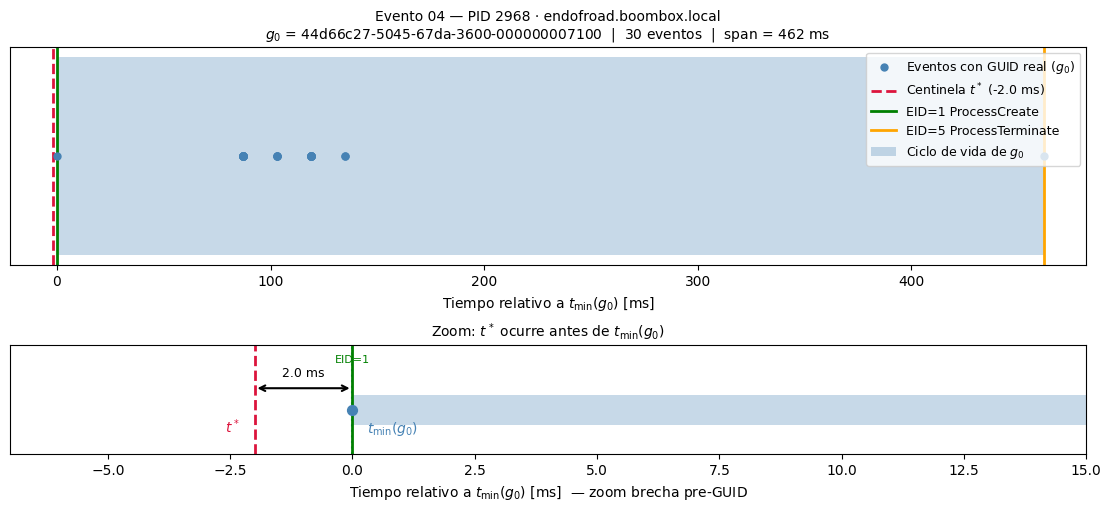

Figura guardada: ../sesion-2/img/ev04_timeline.png


In [339]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# ── Eventos EID=1 y EID=5 para PID 2968 en endofroad ────────────────────────
eid1_proc = df[
    (df['EventID'] == 1) &
    (df['Computer'] == c04) & (df['ProcessId'] == p04)
].sort_values('ts')

eid5_proc = df[
    (df['EventID'] == 5) &
    (df['Computer'] == c04) & (df['ProcessId'] == p04)
].sort_values('ts')

print(f'EID=1 (ProcessCreate)   para PID {int(p04)}: {len(eid1_proc)} evento(s)')
print(f'EID=5 (ProcessTerminate) para PID {int(p04)}: {len(eid5_proc)} evento(s)')
if len(eid1_proc): print(eid1_proc[['ts','ProcessGuid','Image']].to_string(index=False))
if len(eid5_proc): print(eid5_proc[['ts','ProcessGuid','Image']].to_string(index=False))

# ── Offsets en ms relativos a t_min_g0 ──────────────────────────────────────
origin    = t_min_g0
t_star_ms = (t_star   - origin).total_seconds() * 1000
t_min_ms  = 0.0
t_max_ms  = (t_max_g0 - origin).total_seconds() * 1000
ev_ms     = [(t - origin).total_seconds() * 1000 for t in g0_events['ts']]

eid1_ms = [(t - origin).total_seconds() * 1000 for t in eid1_proc['ts']]
eid5_ms = [(t - origin).total_seconds() * 1000 for t in eid5_proc['ts']]

fig, axes = plt.subplots(2, 1, figsize=(11, 5),
                         gridspec_kw={'height_ratios': [2, 1]},
                         constrained_layout=True)

# ── Panel superior: vista completa ───────────────────────────────────────────
ax = axes[0]
ax.barh(0, t_max_ms - t_min_ms, left=t_min_ms, height=0.35,
        color='steelblue', alpha=0.3, label='Ciclo de vida de $g_0$')
ax.scatter(ev_ms, [0]*len(ev_ms), color='steelblue', s=25, zorder=3,
           label='Eventos con GUID real ($g_0$)')
ax.axvline(t_star_ms, color='crimson', linewidth=2, linestyle='--',
           label=f'Centinela $t^*$ ({t_star_ms:.1f} ms)')

# EID=1 y EID=5
for x in eid1_ms:
    ax.axvline(x, color='green', linewidth=2, linestyle='-',
               label='EID=1 ProcessCreate' if x == eid1_ms[0] else '_')
for x in eid5_ms:
    ax.axvline(x, color='orange', linewidth=2, linestyle='-',
               label='EID=5 ProcessTerminate' if x == eid5_ms[0] else '_')

ax.set_xlabel('Tiempo relativo a $t_{\\min}(g_0)$ [ms]')
ax.set_yticks([])
ax.set_title(
    f'Evento 04 — PID 2968 · endofroad.boombox.local\n'
    f'$g_0$ = {g0}  |  {len(g0_events)} eventos  |  span = {t_max_ms:.0f} ms',
    fontsize=10
)
ax.legend(fontsize=9, loc='upper right')
ax.set_xlim(t_star_ms - 20, t_max_ms + 20)

# ── Panel inferior: zoom en la brecha pre-GUID ───────────────────────────────
ax2 = axes[1]
zoom_lo, zoom_hi = t_star_ms - 5, t_min_ms + 15
ax2.barh(0, t_max_ms - t_min_ms, left=t_min_ms, height=0.35,
         color='steelblue', alpha=0.3)
ax2.scatter([ev_ms[0]], [0], color='steelblue', s=50, zorder=3)
ax2.axvline(t_star_ms, color='crimson', linewidth=2, linestyle='--')
ax2.axvline(t_min_ms,  color='steelblue', linewidth=1.5, linestyle=':')

# EID=1 y EID=5 en el zoom (solo si caen en la ventana)
for x in eid1_ms:
    if zoom_lo <= x <= zoom_hi:
        ax2.axvline(x, color='green', linewidth=2)
        ax2.text(x, 0.55, 'EID=1', ha='center', fontsize=8, color='green')
for x in eid5_ms:
    if zoom_lo <= x <= zoom_hi:
        ax2.axvline(x, color='orange', linewidth=2)
        ax2.text(x, 0.55, 'EID=5', ha='center', fontsize=8, color='orange')

ax2.annotate('', xy=(t_min_ms, 0.25), xytext=(t_star_ms, 0.25),
             arrowprops=dict(arrowstyle='<->', color='black', lw=1.5))
ax2.text((t_star_ms + t_min_ms) / 2, 0.35,
         f'{abs(t_star_ms):.1f} ms', ha='center', va='bottom', fontsize=9)
ax2.text(t_star_ms - 0.3, -0.25, '$t^*$', ha='right', color='crimson', fontsize=10)
ax2.text(t_min_ms  + 0.3, -0.25, '$t_{\\min}(g_0)$', ha='left',
         color='steelblue', fontsize=10)
ax2.set_xlim(zoom_lo, zoom_hi)
ax2.set_ylim(-0.5, 0.75)
ax2.set_yticks([])
ax2.set_xlabel('Tiempo relativo a $t_{\\min}(g_0)$ [ms]  — zoom brecha pre-GUID')
ax2.set_title('Zoom: $t^*$ ocurre antes de $t_{\\min}(g_0)$', fontsize=10)

OUT = '../sesion-2/img/ev04_timeline.png'
fig.savefig(OUT, dpi=150, bbox_inches='tight')
plt.show()
print(f'Figura guardada: {OUT}')

### Análisis del evento centinela EID=7

El evento centinela es un **ImageLoad (EID=7)** — Sysmon registra la carga
de `conhost.exe` como imagen ejecutable del proceso. Examinamos todos sus campos
y evaluamos dos hipótesis sobre su propiedad:

- **H1 (auto-carga durante inicialización):** el EID=7 registra la carga de la
  propia imagen de `conhost.exe` en el momento en que el proceso se está
  inicializando. El driver de Sysmon interceptó este evento antes de terminar de
  asignar el GUID (artefacto pre-GUID). El proceso propietario es PID 2968 = $g_0$.
- **H2 (carga por proceso externo):** otro proceso —con GUID centinela propio—
  cargó `conhost.exe` como módulo antes de que existiera el proceso PID 2968.
  En ese caso el GUID correcto no sería $g_0$ sino el del proceso externo.


In [340]:
# Todos los campos del evento centinela e*
print('=== Evento centinela e* — todos los campos ===')
non_null = ev04.dropna()
print(non_null.to_string())

=== Evento centinela e* — todos los campos ===
_original_row_index                                                                      19619
_row_hash                                                                            h3020ee25
EventID                                                                                      7
Computer                                                               endofroad.boombox.local
ProcessGuid                                               00000000-0000-0000-0000-000000000000
ProcessId                                                                               2968.0
Image                                                          C:\Windows\System32\conhost.exe
User                                                                       NT AUTHORITY\SYSTEM
Hashes                 SHA256=32C93F26B1B3DEC2BFCEE6F320AE77615A90AF96C66DE2846BDC8F64165754AA
ImageLoaded                                                    C:\Windows\System32\conhost.exe
Ori

In [341]:
# Proceso creador de conhost.exe: quién lo creó (desde el EID=1)
print('=== EID=1 de conhost.exe (PID 2968) — proceso padre ===')
cols_eid1 = ['ts','ProcessGuid','ProcessId','Image',
             'ParentProcessGuid','ParentProcessId','ParentImage',
             'CommandLine','User']
print(eid1_proc[[c for c in cols_eid1 if c in eid1_proc.columns]].to_string(index=False))

=== EID=1 de conhost.exe (PID 2968) — proceso padre ===
                     ts                          ProcessGuid  ProcessId                           Image                    ParentProcessGuid  ParentProcessId                      ParentImage                                             CommandLine                User
2025-03-19 05:04:05.552 44d66c27-5045-67da-3600-000000007100     2968.0 C:\Windows\System32\conhost.exe 44d66c27-5045-67da-3500-000000007100           2668.0 C:\Windows\System32\dsregcmd.exe \??\C:\Windows\system32\conhost.exe 0xffffffff -ForceV1 NT AUTHORITY\SYSTEM


In [342]:
# Nota: todos los eventos de esta ventana comparten el mismo milisegundo
# (1742360645550). Fueron capturados en el mismo batch de ETW, lo que
# confirma que la densidad de actividad en endofroad fue muy alta en ese
# instante, pero no aporta información direccional sobre la propiedad del
# evento centinela.
# Ventana temporal ±10 ms alrededor de t*: qué más ocurrió en endofroad
DELTA_MS = 10
t_lo = t_star - pd.Timedelta(milliseconds=DELTA_MS)
t_hi = t_star + pd.Timedelta(milliseconds=DELTA_MS)

window = (
    df[(df['Computer'] == c04) & (df['ts'] >= t_lo) & (df['ts'] <= t_hi)]
    .sort_values('ts')
    [['ts','EventID','ProcessGuid','ProcessId','Image','User',
      'SourceIp','SourcePort','DestinationIp','DestinationPort']]
)
window['▶'] = ''
window.loc[window['ProcessId'] == p04, '▶'] = '◀ PID 2968'

print(f'Eventos en endofroad en ventana t* ± {DELTA_MS} ms:')
display(window.reset_index(drop=True))

Eventos en endofroad en ventana t* ± 10 ms:


,ts,EventID,ProcessGuid,ProcessId,Image,User,SourceIp,SourcePort,DestinationIp,DestinationPort,▶
0,2025-03-19 05:04:05.550,7,44d66c27-5043-67da-1f00-000000007100,1552.0,C:\Windows\System32\svchost.exe,NT AUTHORITY\SYSTEM,NaN,NaN,NaN,NaN,
1,2025-03-19 05:04:05.550,13,44d66c27-5044-67da-2900-000000007100,2120.0,C:\Windows\system32\dxgiadaptercache.exe,NT AUTHORITY\SYSTEM,NaN,NaN,NaN,NaN,
2,2025-03-19 05:04:05.550,13,44d66c27-5044-67da-2900-000000007100,2120.0,C:\Windows\system32\dxgiadaptercache.exe,NT AUTHORITY\SYSTEM,NaN,NaN,NaN,NaN,
3,2025-03-19 05:04:05.550,13,44d66c27-5044-67da-2900-000000007100,2120.0,C:\Windows\system32\dxgiadaptercache.exe,NT AUTHORITY\SYSTEM,NaN,NaN,NaN,NaN,
4,2025-03-19 05:04:05.550,7,44d66c27-5044-67da-3200-000000007100,2488.0,C:\Windows\System32\sppsvc.exe,NT AUTHORITY\NETWORK SERVICE,NaN,NaN,NaN,NaN,
5,2025-03-19 05:04:05.550,13,44d66c27-5044-67da-2900-000000007100,2120.0,C:\Windows\system32\dxgiadaptercache.exe,NT AUTHORITY\SYSTEM,NaN,NaN,NaN,NaN,
6,2025-03-19 05:04:05.550,13,44d66c27-5044-67da-2900-000000007100,2120.0,C:\Windows\system32\dxgiadaptercache.exe,NT AUTHORITY\SYSTEM,NaN,NaN,NaN,NaN,
7,2025-03-19 05:04:05.550,13,44d66c27-5044-67da-2900-000000007100,2120.0,C:\Windows\system32\dxgiadaptercache.exe,NT AUTHORITY\SYSTEM,NaN,NaN,NaN,NaN,
8,2025-03-19 05:04:05.550,13,44d66c27-5044-67da-2900-000000007100,2120.0,C:\Windows\system32\dxgiadaptercache.exe,NT AUTHORITY\SYSTEM,NaN,NaN,NaN,NaN,
9,2025-03-19 05:04:05.550,12,44d66c27-5044-67da-2900-000000007100,2120.0,C:\Windows\system32\dxgiadaptercache.exe,NT AUTHORITY\SYSTEM,NaN,NaN,NaN,NaN,


In [343]:
# ¿El proceso padre (ParentProcessId) tiene eventos propios en esa ventana?
parent_pid = eid1_proc['ParentProcessId'].iloc[0] if len(eid1_proc) else None
parent_img = eid1_proc['ParentImage'].iloc[0]      if len(eid1_proc) else None

print(f'Proceso padre de conhost.exe: PID={parent_pid}, Image={parent_img}')
print()

if parent_pid:
    parent_events = (
        df[(df['Computer'] == c04) &
           (df['ProcessId'] == parent_pid) &
           (df['ts'] >= t_lo) & (df['ts'] <= t_hi)]
        .sort_values('ts')
        [['ts','EventID','ProcessGuid','ProcessId','Image',
          'SourceIp','SourcePort','DestinationIp','DestinationPort']]
    )
    print(f'Eventos del proceso padre (PID {int(parent_pid)}) en ventana t* ± {DELTA_MS} ms:')
    if len(parent_events):
        display(parent_events.reset_index(drop=True))
    else:
        print('  Ninguno en esa ventana.')

Proceso padre de conhost.exe: PID=2668.0, Image=C:\Windows\System32\dsregcmd.exe

Eventos del proceso padre (PID 2668) en ventana t* ± 10 ms:
  Ninguno en esa ventana.


---
### H1 vs H2: evidencia desde los datos

Para decidir entre las dos hipótesis examinamos tres piezas de evidencia:

1. **`ImageLoaded`**: si el campo contiene `conhost.exe` (mismo ejecutable que
   `Image`), estamos ante una auto-carga → señal fuerte de H1.
2. **Usuario**: si coincide con el del EID=1 de PID 2968, apoya H1.
3. **Ausencia de proceso alternativo**: si no existe ningún otro proceso con
   PID 2968 en `endofroad` en el instante $t^*$, H2 no tiene soporte.


In [344]:
# Evidencia 1: ImageLoaded del evento centinela
print('=== Campos ImageLoad del evento centinela ===')
print(f"Image       : {ev04.get('Image', 'N/A')}")
print(f"ImageLoaded : {ev04.get('ImageLoaded', 'N/A')}")
print(f"User        : {ev04.get('User', 'N/A')}")
print()

# Auto-carga: Image == ImageLoaded
auto_load = str(ev04.get('Image','')).lower() == str(ev04.get('ImageLoaded','')).lower()
print(f'Image == ImageLoaded (auto-carga): {auto_load}')
print()

# Evidencia 2: usuario del EID=1 de g0
user_eid1 = eid1_proc['User'].iloc[0] if len(eid1_proc) else 'N/A'
user_sent  = ev04.get('User', 'N/A')
print(f'User en EID=1 (g0) : {user_eid1}')
print(f'User en centinela  : {user_sent}')
print(f'Coinciden          : {str(user_eid1).lower() == str(user_sent).lower()}')
print()

# Evidencia 3: ¿hay otro proceso con PID 2968 antes de t*?
otros_pid = df[
    (df['Computer'] == c04) &
    (df['ProcessId'] == p04) &
    (df['ts'] < t_star) &
    (df['ProcessGuid'] != NULL_GUID)
]
print(f'Eventos con PID {int(p04)} y GUID real ANTES de t*: {len(otros_pid)}')
if len(otros_pid):
    print(otros_pid[['ts','EventID','ProcessGuid','Image']].head())
else:
    print('  → Ninguno. No hay evidencia de un proceso previo con PID 2968.')


=== Campos ImageLoad del evento centinela ===
Image       : C:\Windows\System32\conhost.exe
ImageLoaded : C:\Windows\System32\conhost.exe
User        : NT AUTHORITY\SYSTEM

Image == ImageLoaded (auto-carga): True

User en EID=1 (g0) : NT AUTHORITY\SYSTEM
User en centinela  : NT AUTHORITY\SYSTEM
Coinciden          : True

Eventos con PID 2968 y GUID real ANTES de t*: 0
  → Ninguno. No hay evidencia de un proceso previo con PID 2968.


### Conclusión: H1 confirmada — `REPLACE_GUID` con extensión δ

Las tres evidencias apuntan inequívocamente a **H1**:

| Evidencia | Resultado |
|-----------|-----------|
| `ImageLoaded == Image` (auto-carga) | ✓ `conhost.exe` carga su propia imagen |
| Usuario idéntico en centinela y EID=1 | ✓ `NT AUTHORITY\SYSTEM` en ambos |
| Sin proceso previo con PID 2968 y GUID real | ✓ No existe candidato alternativo para H2 |

**Mecanismo (H1):** durante la inicialización de `conhost.exe`, el kernel
notifica a Sysmon la carga de la imagen ejecutable (EID=7) antes de que el
driver haya procesado el EID=1 y asignado el GUID al proceso. El resultado
es un evento centinela que precede a $t_{\min}(g_0)$ por exactamente **2 ms**
— la ventana en que el GUID aún no estaba disponible.

La regla de recuperación queda confirmada para este evento:

$$
t_{\min}(g_0) - \delta \leq t^* \quad (\delta = 2\,\text{ms}) \implies \texttt{REPLACE\_GUID}
$$

$g_0 =$ `44d66c27-5045-67da-3600-000000007100` es el GUID correcto para el evento centinela.


---
## Caso $\lvert\mathcal{G}\rvert = 1$ — Grupo eventos 05–23

**PID 1972 · `diskjockey.boombox.local` · filas 22960–22993 (19 eventos)**  
`C:\Windows\System32\taskhostw.exe`

Los 19 eventos centinela de este grupo comparten el mismo `(ProcessId, Computer)`,
por lo que $\mathcal{G}(1972,\, \texttt{diskjockey})$ es idéntico para todos.
Se analizan como un único caso.

In [345]:
# Grupo PID 1972 — resumen de los 19 eventos centinela
# Todos son EID=7 (ImageLoad): taskhostw.exe cargando sus módulos en la fase
# de inicialización, antes de que el driver asignara el GUID al proceso.
grupo = sentinel_k1[sentinel_k1['ProcessId'] == 1972].copy()

print(f'Eventos centinela : {len(grupo)}')
print(f'EventIDs          : {sorted(grupo["EventID"].unique())}')
print(f'Timestamps únicos : {grupo["ts"].nunique()} → {grupo["ts"].iloc[0]}')
print()

cols = ['_original_row_index', 'ts', 'EventID',
        'Computer', 'ProcessId', 'Image', 'ProcessGuid', 'ImageLoaded']
available = [c for c in cols if c in grupo.columns]
print('Detalle de los 19 eventos (ProcessGuid = ∅ en todos):')
display(grupo[available].reset_index(drop=True))

Eventos centinela : 19
EventIDs          : [np.int64(7)]
Timestamps únicos : 1 → 2025-03-19 05:04:29.691000

Detalle de los 19 eventos (ProcessGuid = ∅ en todos):


,_original_row_index,ts,EventID,Computer,ProcessId,Image,ProcessGuid,ImageLoaded
0,22960,2025-03-19 05:04:29.691,7,diskjockey.boombox.local,1972.0,C:\Windows\System32\taskhostw.exe,00000000-0000-0000-0000-000000000000,C:\Windows\System32\combase.dll
1,22961,2025-03-19 05:04:29.691,7,diskjockey.boombox.local,1972.0,C:\Windows\System32\taskhostw.exe,00000000-0000-0000-0000-000000000000,C:\Windows\System32\imm32.dll
2,22962,2025-03-19 05:04:29.691,7,diskjockey.boombox.local,1972.0,C:\Windows\System32\taskhostw.exe,00000000-0000-0000-0000-000000000000,C:\Windows\System32\sechost.dll
3,22963,2025-03-19 05:04:29.691,7,diskjockey.boombox.local,1972.0,C:\Windows\System32\taskhostw.exe,00000000-0000-0000-0000-000000000000,C:\Windows\System32\clbcatq.dll
4,22964,2025-03-19 05:04:29.691,7,diskjockey.boombox.local,1972.0,C:\Windows\System32\taskhostw.exe,00000000-0000-0000-0000-000000000000,C:\Windows\System32\win32u.dll
5,22965,2025-03-19 05:04:29.691,7,diskjockey.boombox.local,1972.0,C:\Windows\System32\taskhostw.exe,00000000-0000-0000-0000-000000000000,C:\Windows\System32\rpcrt4.dll
6,22969,2025-03-19 05:04:29.691,7,diskjockey.boombox.local,1972.0,C:\Windows\System32\taskhostw.exe,00000000-0000-0000-0000-000000000000,C:\Windows\System32\oleaut32.dll
7,22971,2025-03-19 05:04:29.691,7,diskjockey.boombox.local,1972.0,C:\Windows\System32\taskhostw.exe,00000000-0000-0000-0000-000000000000,C:\Windows\System32\ucrtbase.dll
8,22982,2025-03-19 05:04:29.691,7,diskjockey.boombox.local,1972.0,C:\Windows\System32\taskhostw.exe,00000000-0000-0000-0000-000000000000,C:\Windows\System32\dimsjob.dll
9,22983,2025-03-19 05:04:29.691,7,diskjockey.boombox.local,1972.0,C:\Windows\System32\taskhostw.exe,00000000-0000-0000-0000-000000000000,C:\Windows\System32\pautoenr.dll


In [346]:
# G(p,c) y verificación temporal — grupo PID 1972
import pandas as pd

p_g = 1972
c_g = 'diskjockey.boombox.local'
t_star_g = grupo['ts'].iloc[0]   # todos comparten el mismo timestamp

G_g = compute_G(df, p_g, c_g)
g0_g = list(G_g)[0]
print(f'G({p_g}, {c_g}) = {{{g0_g}}}')
print(f'|G| = {len(G_g)}')
print()

# Ciclo de vida L(g0): g0 en las cuatro columnas GUID
k1_g = df[df['ProcessGuid']       == g0_g][['ts','EventID','ProcessId','Image','Computer']].assign(kpair='k1')
k2_g = df[df['ParentProcessGuid'] == g0_g][['ts','EventID','ProcessId','Image','Computer']].assign(kpair='k2')
k3_g = df[df['SourceProcessGUID'] == g0_g][['ts','EventID','ProcessId','Image','Computer']].assign(kpair='k3') if 'SourceProcessGUID' in df.columns else pd.DataFrame()
k4_g = df[df['TargetProcessGUID'] == g0_g][['ts','EventID','ProcessId','Image','Computer']].assign(kpair='k4') if 'TargetProcessGUID' in df.columns else pd.DataFrame()

L_g = pd.concat([k1_g, k2_g, k3_g, k4_g]).dropna(subset=['ts']).sort_values('ts')

print('Eventos de g0 por k-pair:')
print(L_g['kpair'].value_counts().sort_index())
print()

t_min_g = L_g['ts'].min()
t_max_g = L_g['ts'].max()
gap_ms  = (t_min_g - t_star_g).total_seconds() * 1000   # positivo si t* < t_min

print(f't_min(g0) = {t_min_g}')
print(f't*        = {t_star_g}')
print(f't_max(g0) = {t_max_g}')
print(f'gap t* → t_min = {gap_ms:.1f} ms  (negativo = t* después de t_min)')
print()

dentro = t_min_g <= t_star_g <= t_max_g
accion = 'REPLACE_GUID' if dentro else 'REVIEW (t* fuera del ciclo de vida de g0)'
print(f't_min <= t* <= t_max : {dentro}')
print(f'Acción               : {accion}')
print(f'Total eventos L(g0)  : {len(L_g)}  |  span = {(t_max_g - t_min_g).total_seconds()*1000:.0f} ms')

G(1972, diskjockey.boombox.local) = {2d5a9c51-505d-67da-2600-000000009000}
|G| = 1

Eventos de g0 por k-pair:
kpair
k1    37
k4     8
Name: count, dtype: int64

t_min(g0) = 2025-03-19 05:04:29.691000
t*        = 2025-03-19 05:04:29.691000
t_max(g0) = 2025-03-19 05:04:34.280000
gap t* → t_min = 0.0 ms  (negativo = t* después de t_min)

t_min <= t* <= t_max : True
Acción               : REPLACE_GUID
Total eventos L(g0)  : 45  |  span = 4589 ms


In [347]:
# Todos los eventos de L(g0): reconstruimos con columnas completas desde df
# Para k1: ProcessGuid/ProcessId/Image son del proceso activo
# Para k4: ProcessGuid/ProcessId/Image son del proceso ORIGEN del acceso;
#          TargetProcessGUID/TargetProcessId/TargetImage son del proceso OBJETIVO (= g0)

cols_base   = ['ts', 'EventID', 'Computer', 'ProcessId', 'Image', 'ProcessGuid']
cols_target = ['SourceProcessId', 'SourceProcessGUID', 'SourceImage', 'TargetProcessId', 'TargetProcessGUID', 'TargetImage']
cols_all    = cols_base + [c for c in cols_target if c in df.columns]

# Recuperar índices originales de L_g para obtener columnas adicionales
L_full = df.loc[L_g.index, cols_all].copy()
L_full.insert(0, 'kpair', L_g['kpair'].values)
L_full = L_full.sort_values('ts').reset_index(drop=True)

print(f'Total eventos L(g0): {len(L_full)}  (k1={len(L_g[L_g.kpair=="k1"])}, k4={len(L_g[L_g.kpair=="k4"])})')
print()
display(L_full)

Total eventos L(g0): 45  (k1=37, k4=8)



,kpair,ts,EventID,Computer,ProcessId,Image,ProcessGuid,SourceProcessId,SourceProcessGUID,SourceImage,TargetProcessId,TargetProcessGUID,TargetImage
0,k1,2025-03-19 05:04:29.691,7,diskjockey.boombox.local,1972.0,C:\Windows\System32\taskhostw.exe,2d5a9c51-505d-67da-2600-000000009000,NaN,NaN,NaN,NaN,NaN,NaN
1,k1,2025-03-19 05:04:29.691,7,diskjockey.boombox.local,1972.0,C:\Windows\System32\taskhostw.exe,2d5a9c51-505d-67da-2600-000000009000,NaN,NaN,NaN,NaN,NaN,NaN
2,k1,2025-03-19 05:04:29.691,7,diskjockey.boombox.local,1972.0,C:\Windows\System32\taskhostw.exe,2d5a9c51-505d-67da-2600-000000009000,NaN,NaN,NaN,NaN,NaN,NaN
3,k1,2025-03-19 05:04:29.691,12,diskjockey.boombox.local,1972.0,C:\Windows\system32\taskhostw.exe,2d5a9c51-505d-67da-2600-000000009000,NaN,NaN,NaN,NaN,NaN,NaN
4,k4,2025-03-19 05:04:29.691,10,diskjockey.boombox.local,NaN,NaN,NaN,992.0,2d5a9c51-cee0-67da-1100-000000009000,C:\Windows\system32\svchost.exe,1972.0,2d5a9c51-505d-67da-2600-000000009000,C:\Windows\system32\taskhostw.exe
5,k1,2025-03-19 05:04:29.691,7,diskjockey.boombox.local,1972.0,C:\Windows\System32\taskhostw.exe,2d5a9c51-505d-67da-2600-000000009000,NaN,NaN,NaN,NaN,NaN,NaN
6,k4,2025-03-19 05:04:29.691,10,diskjockey.boombox.local,NaN,NaN,NaN,376.0,2d5a9c51-cede-67da-0600-000000009000,C:\Windows\system32\csrss.exe,1972.0,2d5a9c51-505d-67da-2600-000000009000,C:\Windows\system32\taskhostw.exe
7,k4,2025-03-19 05:04:29.691,10,diskjockey.boombox.local,NaN,NaN,NaN,800.0,2d5a9c51-cee0-67da-0d00-000000009000,C:\Windows\system32\svchost.exe,1972.0,2d5a9c51-505d-67da-2600-000000009000,C:\Windows\system32\taskhostw.exe
8,k4,2025-03-19 05:04:29.691,10,diskjockey.boombox.local,NaN,NaN,NaN,852.0,2d5a9c51-cee0-67da-0e00-000000009000,C:\Windows\system32\svchost.exe,1972.0,2d5a9c51-505d-67da-2600-000000009000,C:\Windows\system32\taskhostw.exe
9,k4,2025-03-19 05:04:29.691,10,diskjockey.boombox.local,NaN,NaN,NaN,992.0,2d5a9c51-cee0-67da-1100-000000009000,C:\Windows\system32\svchost.exe,1972.0,2d5a9c51-505d-67da-2600-000000009000,C:\Windows\system32\taskhostw.exe


EID=1 (ProcessCreate)    para PID 1972: 1 evento(s)
EID=5 (ProcessTerminate) para PID 1972: 1 evento(s)


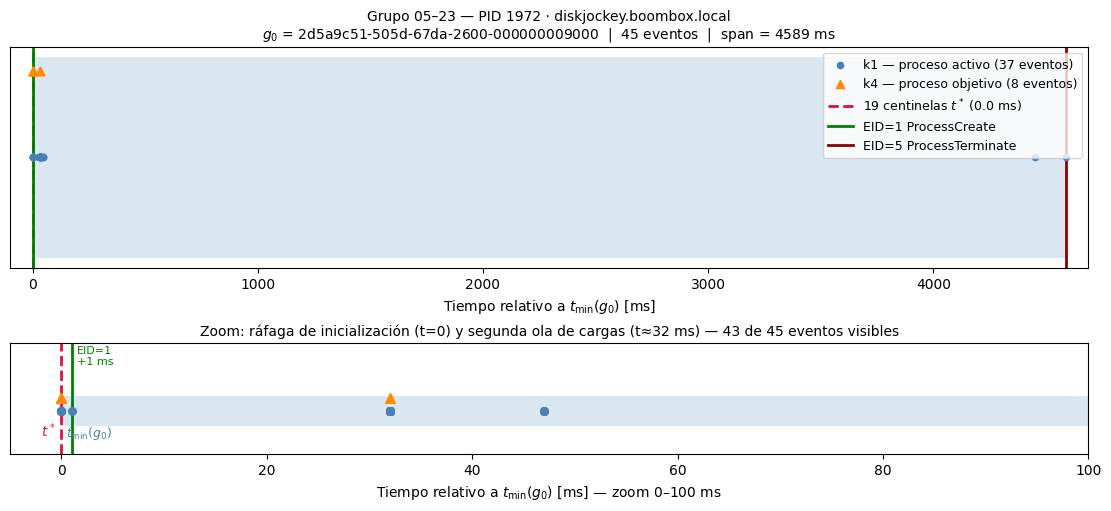

Figura guardada: ../sesion-2/img/ev05_23_timeline.png


In [348]:
import matplotlib.pyplot as plt

# ── EID=1 y EID=5 para PID 1972 en diskjockey ───────────────────────────────
eid1_g = df[(df['EventID']==1) & (df['Computer']==c_g) & (df['ProcessId']==p_g)].sort_values('ts')
eid5_g = df[(df['EventID']==5) & (df['Computer']==c_g) & (df['ProcessId']==p_g)].sort_values('ts')

print(f'EID=1 (ProcessCreate)    para PID {p_g}: {len(eid1_g)} evento(s)')
print(f'EID=5 (ProcessTerminate) para PID {p_g}: {len(eid5_g)} evento(s)')

# ── Offsets en ms relativos a t_min_g ───────────────────────────────────────
origin  = t_min_g
star_ms = (t_star_g - origin).total_seconds() * 1000
max_ms  = (t_max_g  - origin).total_seconds() * 1000

k1_ms   = [(t - origin).total_seconds()*1000 for t in L_g[L_g['kpair']=='k1']['ts']]
k4_ms   = [(t - origin).total_seconds()*1000 for t in L_g[L_g['kpair']=='k4']['ts']]
eid1_ms = [(t - origin).total_seconds()*1000 for t in eid1_g['ts']]
eid5_ms = [(t - origin).total_seconds()*1000 for t in eid5_g['ts']]

fig, axes = plt.subplots(2, 1, figsize=(11, 5),
                         gridspec_kw={'height_ratios': [2, 1]},
                         constrained_layout=True)

# ── Panel superior: vista completa ───────────────────────────────────────────
ax = axes[0]
ax.barh(0, max_ms, left=0, height=0.35, color='steelblue', alpha=0.2)
ax.scatter(k1_ms, [0]*len(k1_ms), color='steelblue', s=20, zorder=3,
           label=f'k1 — proceso activo ({len(k1_ms)} eventos)')
ax.scatter(k4_ms, [0.15]*len(k4_ms), color='darkorange', s=35, marker='^', zorder=3,
           label=f'k4 — proceso objetivo ({len(k4_ms)} eventos)')
ax.axvline(star_ms, color='crimson', linewidth=2, linestyle='--',
           label=f'19 centinelas $t^*$ ({star_ms:.1f} ms)')
for x in eid1_ms:
    ax.axvline(x, color='green', linewidth=2,
               label='EID=1 ProcessCreate' if x == eid1_ms[0] else '_')
for x in eid5_ms:
    ax.axvline(x, color='darkred', linewidth=2,
               label='EID=5 ProcessTerminate' if x == eid5_ms[0] else '_')
ax.set_xlabel('Tiempo relativo a $t_{\min}(g_0)$ [ms]')
ax.set_yticks([])
ax.set_title(
    f'Grupo 05–23 — PID {p_g} · {c_g}\n'
    f'$g_0$ = {g0_g}  |  {len(L_g)} eventos  |  span = {max_ms:.0f} ms',
    fontsize=10)
ax.legend(fontsize=9, loc='upper right')
ax.set_xlim(star_ms - 100, max_ms + 100)

# ── Panel inferior: zoom 0–100 ms ────────────────────────────────────────────
ax2 = axes[1]
zoom_lo, zoom_hi = star_ms - 5, 100
ax2.barh(0, max_ms, left=0, height=0.35, color='steelblue', alpha=0.2)

k1_zoom = [x for x in k1_ms if zoom_lo <= x <= zoom_hi]
k4_zoom = [x for x in k4_ms if zoom_lo <= x <= zoom_hi]
ax2.scatter(k1_zoom, [0]*len(k1_zoom), color='steelblue', s=30, zorder=3)
ax2.scatter(k4_zoom, [0.15]*len(k4_zoom), color='darkorange', s=45, marker='^', zorder=3)
ax2.axvline(star_ms, color='crimson', linewidth=2, linestyle='--')
for x in eid1_ms:
    if zoom_lo <= x <= zoom_hi:
        ax2.axvline(x, color='green', linewidth=2)
        ax2.text(x + 0.5, 0.55, f'EID=1\n+{x:.0f} ms', ha='left', fontsize=8, color='green')
for x in eid5_ms:
    if zoom_lo <= x <= zoom_hi:
        ax2.axvline(x, color='darkred', linewidth=2)

ax2.text(star_ms - 0.5, -0.3, '$t^*$', ha='right', color='crimson', fontsize=10)
ax2.text(0.5, -0.3, '$t_{\min}(g_0)$', ha='left', color='steelblue', fontsize=9)
ax2.set_xlim(zoom_lo, zoom_hi)
ax2.set_ylim(-0.5, 0.8)
ax2.set_yticks([])
ax2.set_xlabel('Tiempo relativo a $t_{\min}(g_0)$ [ms] — zoom 0–100 ms')
ax2.set_title(
    f'Zoom: ráfaga de inicialización (t=0) y segunda ola de cargas (t≈32 ms) — '
    f'{len(k1_zoom)+len(k4_zoom)} de {len(L_g)} eventos visibles',
    fontsize=10)

OUT = '../sesion-2/img/ev05_23_timeline.png'
fig.savefig(OUT, dpi=150, bbox_inches='tight')
plt.show()
print(f'Figura guardada: {OUT}')

In [349]:
# EID=1: proceso creador de taskhostw.exe (PID 1972)
print('=== EID=1 de taskhostw.exe (PID 1972) ===')
cols_eid1 = ['ts', 'ProcessGuid', 'ProcessId', 'Image',
             'ParentProcessGuid', 'ParentProcessId', 'ParentImage',
             'CommandLine', 'User']
print(eid1_g[[c for c in cols_eid1 if c in eid1_g.columns]].to_string(index=False))
print()
parent_guid = eid1_g['ParentProcessGuid'].iloc[0]
if parent_guid == NULL_GUID:
    print('Nota: ParentProcessGuid = ∅ — violación k=2 independiente, fuera del scope k=1.')

=== EID=1 de taskhostw.exe (PID 1972) ===
                     ts                          ProcessGuid  ProcessId                             Image                    ParentProcessGuid  ParentProcessId ParentImage          CommandLine                User
2025-03-19 05:04:29.692 2d5a9c51-505d-67da-2600-000000009000     1972.0 C:\Windows\System32\taskhostw.exe 00000000-0000-0000-0000-000000000000            992.0           - taskhostw.exe SYSTEM NT AUTHORITY\SYSTEM

Nota: ParentProcessGuid = ∅ — violación k=2 independiente, fuera del scope k=1.


---
### Conclusión — Grupo 05–23: `PRE_GUID_INIT`, gap = 0 ms

**Patrón:** idéntico al evento 04 — los 19 eventos centinela son EID=7 (ImageLoad)
capturados durante la inicialización de `taskhostw.exe` antes de que el driver
asignara $g_0$.

**Diferencias respecto al evento 04:**

| Aspecto | Evento 04 (`conhost.exe`) | Grupo 05–23 (`taskhostw.exe`) |
|---------|---------------------------|-------------------------------|
| Centinelas | 1 | 19 |
| Gap $t^* - t_{\min}(g_0)$ | −2 ms | 0 ms |
| DLLs pre-GUID | 1 (auto-carga) | 19 (host COM con muchas dependencias) |
| k4 en $\mathcal{L}(g_0)$ | 0 | 8 (EID=10, procesos del sistema) |
| `ParentProcessGuid` en EID=1 | GUID real | $\emptyset$ (artefacto independiente) |

**Sobre `ParentProcessGuid = ∅`:** el proceso creador (`svchost.exe`, PID 992)
tiene GUID centinela en el campo `ParentProcessGuid` del EID=1. Sin embargo,
`compute_G(992, diskjockey)` recupera su GUID real
`2d5a9c51-cee0-67da-1100-000000009000` — un proceso de boot con 1886 eventos,
anterior a la inicialización de Sysmon (sin EID=1 propio).

**Acción de recuperación:**

$$
t_{\min}(g_0) - \delta \leq t^* \quad (\delta = 0\,\text{ms})
\implies \texttt{REPLACE\_GUID} \quad [\texttt{PRE\_GUID\_INIT}]
$$

$g_0 =$ `2d5a9c51-505d-67da-2600-000000009000` es el GUID correcto
para los **19 eventos centinela** del grupo.


---
## Caso $\lvert\mathcal{G}\rvert = 1$ — Evento 24

**PID 3088 · `diskjockey.boombox.local` · fila 26579**  
`C:\Windows\System32\cmd.exe`

Tercer caso individual con $|\mathcal{G}|=1$. El centinela es también EID=7
(ImageLoad). Analizamos si el patrón PRE_GUID_INIT se repite, y examinamos
el contexto de ejecución: un `cmd.exe` lanzado por otro `cmd.exe` con
`CommandLine = cmd.exe /c sc.exe qc npcap` — consulta del servicio npcap.

In [350]:
# Evento centinela e* — evento 24
ev24     = sentinel_k1.iloc[24]
t_star24 = ev24['ts']
p24      = ev24['ProcessId']
c24      = ev24['Computer']

print('=== Evento centinela e* ===')
print(ev24[['_original_row_index','EventID','Computer','ProcessId','Image','ts']].to_string())

# G(p, c) cruzado por los 4 k-pairs
G24   = compute_G(df, p24, c24)
g0_24 = list(G24)[0]
print(f'\nG({int(p24)}, {c24}) = {{{g0_24}}}')
print(f'|G| = {len(G24)}  →  candidato único: {g0_24}')

# Campos ImageLoad del centinela
print('\n=== Campos EID=7 del centinela ===')
print(f"Image       : {ev24.get('Image', 'N/A')}")
print(f"ImageLoaded : {ev24.get('ImageLoaded', 'N/A')}")
print(f"User        : {ev24.get('User', 'N/A')}")
auto_load24 = str(ev24.get('Image','')).lower() == str(ev24.get('ImageLoaded','')).lower()
print(f'Image == ImageLoaded (auto-carga): {auto_load24}')

=== Evento centinela e* ===
_original_row_index                          26579
EventID                                          7
Computer                  diskjockey.boombox.local
ProcessId                                   3088.0
Image                  C:\Windows\System32\cmd.exe
ts                      2025-03-19 05:04:35.485000

G(3088, diskjockey.boombox.local) = {2d5a9c51-5063-67da-4e00-000000009000}
|G| = 1  →  candidato único: 2d5a9c51-5063-67da-4e00-000000009000

=== Campos EID=7 del centinela ===
Image       : C:\Windows\System32\cmd.exe
ImageLoaded : C:\Windows\System32\cmd.exe
User        : NT AUTHORITY\SYSTEM
Image == ImageLoaded (auto-carga): True


In [351]:
# Ciclo de vida L(g0) — evento 24: g0 en las cuatro columnas GUID
k1_24 = df[df["ProcessGuid"]       == g0_24][["ts","EventID","ProcessId","Image","Computer"]].assign(kpair="k1")
k2_24 = df[df["ParentProcessGuid"] == g0_24][["ts","EventID","ProcessId","Image","Computer"]].assign(kpair="k2")
k3_24 = df[df["SourceProcessGUID"] == g0_24][["ts","EventID","ProcessId","Image","Computer"]].assign(kpair="k3") if "SourceProcessGUID" in df.columns else pd.DataFrame()
k4_24 = df[df["TargetProcessGUID"] == g0_24][["ts","EventID","ProcessId","Image","Computer"]].assign(kpair="k4") if "TargetProcessGUID" in df.columns else pd.DataFrame()

L_24 = pd.concat([k1_24, k2_24, k3_24, k4_24]).dropna(subset=["ts"]).sort_values("ts")

print("Eventos de g0 por k-pair:")
print(L_24["kpair"].value_counts().sort_index())
print()

t_min_24 = L_24["ts"].min()
t_max_24 = L_24["ts"].max()
gap_ms24 = (t_min_24 - t_star24).total_seconds() * 1000

print(f"t_min(g0) = {t_min_24}")
print(f"t*        = {t_star24}")
print(f"t_max(g0) = {t_max_24}")
print(f"gap t* -> t_min = {gap_ms24:.1f} ms  (positivo = t* precede a t_min)")
print()

dentro_24 = t_min_24 <= t_star24 <= t_max_24
accion_24 = "REPLACE_GUID [PRE_GUID_INIT]" if gap_ms24 >= 0 else "REVIEW (t* fuera del ciclo de vida)"
print(f"t_min <= t* <= t_max : {dentro_24}")
print(f"Accion               : {accion_24}")
print(f"Total eventos L(g0)  : {len(L_24)}  |  span = {(t_max_24-t_min_24).total_seconds()*1000:.0f} ms")

# Tabla completa de L(g0) con columnas extra para EID=10
cols_base  = ["ts", "EventID", "kpair", "Computer", "ProcessId", "Image", "ProcessGuid"]
cols_extra = ["SourceProcessId","SourceProcessGUID","SourceImage",
              "TargetProcessId","TargetProcessGUID","TargetImage"]
cols_avail = cols_base + [c for c in cols_extra if c in df.columns]

L_24_full = df.loc[L_24.index, [c for c in cols_avail if c != "kpair"]].copy()
L_24_full.insert(0, "kpair", L_24["kpair"].values)
L_24_full = L_24_full.sort_values("ts").reset_index(drop=True)

# Avisar de procesos hijos (EID=1 en k2)
hijos = L_24_full[(L_24_full["kpair"] == "k2") & (L_24_full["EventID"] == 1)]
if len(hijos):
    print()
    print("*** EID=1 en k2 — proceso(s) hijo(s) de g0:")
    print(hijos[["ts","EventID","kpair","ProcessId","Image"]].to_string(index=False))

print()
display(L_24_full)

Eventos de g0 por k-pair:
kpair
k1    11
k2     1
k3     1
k4     3
Name: count, dtype: int64

t_min(g0) = 2025-03-19 05:04:35.485000
t*        = 2025-03-19 05:04:35.485000
t_max(g0) = 2025-03-19 05:04:35.503000
gap t* -> t_min = 0.0 ms  (positivo = t* precede a t_min)

t_min <= t* <= t_max : True
Accion               : REPLACE_GUID [PRE_GUID_INIT]
Total eventos L(g0)  : 16  |  span = 18 ms

*** EID=1 en k2 — proceso(s) hijo(s) de g0:
                     ts  EventID kpair  ProcessId                      Image
2025-03-19 05:04:35.503        1    k2     3684.0 C:\Windows\System32\sc.exe



,kpair,ts,EventID,Computer,ProcessId,Image,ProcessGuid,SourceProcessId,SourceProcessGUID,SourceImage,TargetProcessId,TargetProcessGUID,TargetImage
0,k1,2025-03-19 05:04:35.485,7,diskjockey.boombox.local,3088.0,C:\Windows\System32\cmd.exe,2d5a9c51-5063-67da-4e00-000000009000,NaN,NaN,NaN,NaN,NaN,NaN
1,k1,2025-03-19 05:04:35.485,7,diskjockey.boombox.local,3088.0,C:\Windows\System32\cmd.exe,2d5a9c51-5063-67da-4e00-000000009000,NaN,NaN,NaN,NaN,NaN,NaN
2,k1,2025-03-19 05:04:35.485,7,diskjockey.boombox.local,3088.0,C:\Windows\System32\cmd.exe,2d5a9c51-5063-67da-4e00-000000009000,NaN,NaN,NaN,NaN,NaN,NaN
3,k1,2025-03-19 05:04:35.485,7,diskjockey.boombox.local,3088.0,C:\Windows\System32\cmd.exe,2d5a9c51-5063-67da-4e00-000000009000,NaN,NaN,NaN,NaN,NaN,NaN
4,k1,2025-03-19 05:04:35.485,7,diskjockey.boombox.local,3088.0,C:\Windows\System32\cmd.exe,2d5a9c51-5063-67da-4e00-000000009000,NaN,NaN,NaN,NaN,NaN,NaN
5,k1,2025-03-19 05:04:35.485,7,diskjockey.boombox.local,3088.0,C:\Windows\System32\cmd.exe,2d5a9c51-5063-67da-4e00-000000009000,NaN,NaN,NaN,NaN,NaN,NaN
6,k1,2025-03-19 05:04:35.485,7,diskjockey.boombox.local,3088.0,C:\Windows\System32\cmd.exe,2d5a9c51-5063-67da-4e00-000000009000,NaN,NaN,NaN,NaN,NaN,NaN
7,k1,2025-03-19 05:04:35.485,7,diskjockey.boombox.local,3088.0,C:\Windows\System32\cmd.exe,2d5a9c51-5063-67da-4e00-000000009000,NaN,NaN,NaN,NaN,NaN,NaN
8,k4,2025-03-19 05:04:35.485,10,diskjockey.boombox.local,NaN,NaN,NaN,1648.0,2d5a9c51-5053-67da-1e00-000000009000,C:\Windows\system32\conhost.exe,3088.0,2d5a9c51-5063-67da-4e00-000000009000,C:\Windows\system32\cmd.exe
9,k4,2025-03-19 05:04:35.485,10,diskjockey.boombox.local,NaN,NaN,NaN,376.0,2d5a9c51-cede-67da-0600-000000009000,C:\Windows\system32\csrss.exe,3088.0,2d5a9c51-5063-67da-4e00-000000009000,C:\Windows\system32\cmd.exe


In [352]:
# EID=1: proceso creador de cmd.exe (PID 3088)
eid1_24 = df[
    (df["EventID"] == 1) &
    (df["Computer"] == c24) &
    (df["ProcessId"] == p24)
].sort_values("ts")

cols_eid1 = ["ts","ProcessGuid","ProcessId","Image",
             "ParentProcessGuid","ParentProcessId","ParentImage",
             "CommandLine","User"]
print("=== EID=1 de cmd.exe (PID 3088) ===")
print(eid1_24[[c for c in cols_eid1 if c in eid1_24.columns]].to_string(index=False))

=== EID=1 de cmd.exe (PID 3088) ===
                     ts                          ProcessGuid  ProcessId                       Image                    ParentProcessGuid  ParentProcessId                 ParentImage                                    CommandLine                User
2025-03-19 05:04:35.488 2d5a9c51-5063-67da-4e00-000000009000     3088.0 C:\Windows\System32\cmd.exe 2d5a9c51-5053-67da-1d00-000000009000           1620.0 C:\Windows\System32\cmd.exe C:\Windows\system32\cmd.exe /c sc.exe qc npcap NT AUTHORITY\SYSTEM


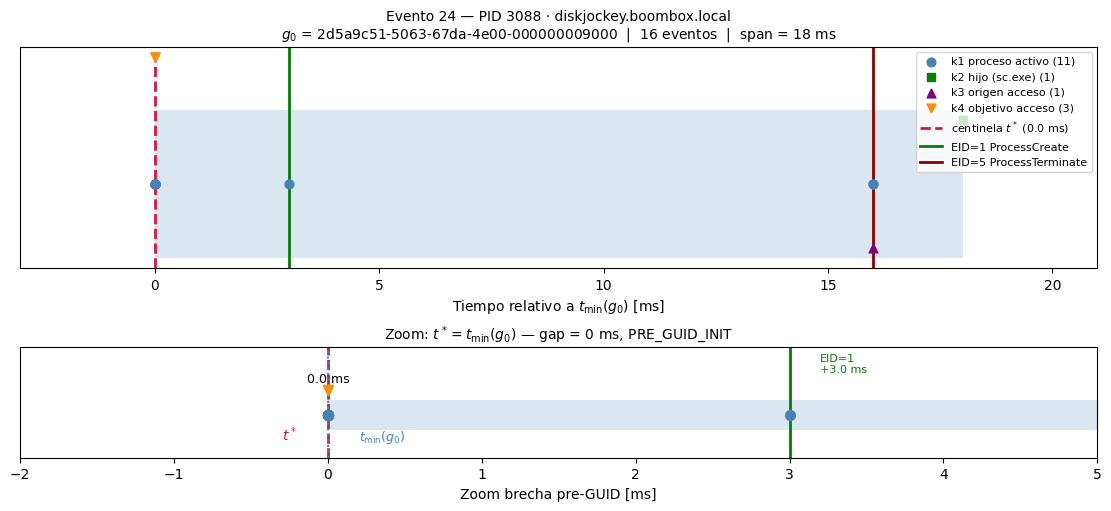

Figura guardada: ../sesion-2/img/ev24_timeline.png


In [353]:
import matplotlib.pyplot as plt

eid5_24 = df[
    (df["EventID"] == 5) & (df["Computer"] == c24) & (df["ProcessId"] == p24)
].sort_values("ts")

origin   = t_min_24
star_ms  = (t_star24  - origin).total_seconds() * 1000
max_ms24 = (t_max_24  - origin).total_seconds() * 1000

by_kpair = {k: L_24[L_24["kpair"] == k]["ts"] for k in ["k1","k2","k3","k4"]}
ms = {k: [(t - origin).total_seconds()*1000 for t in ts] for k, ts in by_kpair.items()}

eid1_ms24 = [(t - origin).total_seconds()*1000 for t in eid1_24["ts"]]
eid5_ms24 = [(t - origin).total_seconds()*1000 for t in eid5_24["ts"]]

fig, axes = plt.subplots(2, 1, figsize=(11, 5),
                         gridspec_kw={"height_ratios": [2, 1]},
                         constrained_layout=True)

# ── Panel superior: vista completa ──────────────────────────────────────────
ax = axes[0]
ax.barh(0, max_ms24, left=0, height=0.35, color="steelblue", alpha=0.2)
colors = {"k1":"steelblue","k2":"green","k3":"purple","k4":"darkorange"}
labels = {"k1":"k1 proceso activo","k2":"k2 hijo (sc.exe)","k3":"k3 origen acceso","k4":"k4 objetivo acceso"}
markers = {"k1":"o","k2":"s","k3":"^","k4":"v"}
y_off  = {"k1":0,"k2":0.15,"k3":-0.15,"k4":0.3}
for k in ["k1","k2","k3","k4"]:
    if ms[k]:
        ax.scatter(ms[k], [y_off[k]]*len(ms[k]),
                   color=colors[k], marker=markers[k], s=40, zorder=3,
                   label=f"{labels[k]} ({len(ms[k])})")
ax.axvline(star_ms, color="crimson", lw=2, ls="--", label=f"centinela $t^*$ ({star_ms:.1f} ms)")
for x in eid1_ms24:
    ax.axvline(x, color="green", lw=2, label="EID=1 ProcessCreate" if x == eid1_ms24[0] else "_")
for x in eid5_ms24:
    ax.axvline(x, color="darkred", lw=2, label="EID=5 ProcessTerminate" if x == eid5_ms24[0] else "_")
ax.set_yticks([])
ax.set_xlabel("Tiempo relativo a $t_{\\min}(g_0)$ [ms]")
ax.set_title(
    f"Evento 24 — PID 3088 · diskjockey.boombox.local\n"
    f"$g_0$ = {g0_24}  |  {len(L_24)} eventos  |  span = {max_ms24:.0f} ms",
    fontsize=10)
ax.legend(fontsize=8, loc="upper right")
ax.set_xlim(star_ms - 3, max_ms24 + 3)

# ── Panel inferior: zoom brecha pre-GUID ────────────────────────────────────
ax2 = axes[1]
zoom_lo, zoom_hi = star_ms - 2, 5
ax2.barh(0, max_ms24, left=0, height=0.35, color="steelblue", alpha=0.2)
for k in ["k1","k2","k3","k4"]:
    pts = [x for x in ms[k] if zoom_lo <= x <= zoom_hi]
    if pts:
        ax2.scatter(pts, [y_off[k]]*len(pts),
                   color=colors[k], marker=markers[k], s=50, zorder=3)
ax2.axvline(star_ms, color="crimson", lw=2, ls="--")
ax2.axvline(0, color="steelblue", lw=1.5, ls=":")
for x in eid1_ms24:
    if zoom_lo <= x <= zoom_hi:
        ax2.axvline(x, color="green", lw=2)
        ax2.text(x + 0.2, 0.5, f"EID=1\n+{x:.1f} ms", ha="left", fontsize=8, color="green")
ax2.annotate("", xy=(0, 0.25), xytext=(star_ms, 0.25),
             arrowprops=dict(arrowstyle="<->", color="black", lw=1.5))
ax2.text((star_ms)/2, 0.35, f"{abs(star_ms):.1f} ms",
         ha="center", va="bottom", fontsize=9)
ax2.text(star_ms - 0.2, -0.3, "$t^*$", ha="right", color="crimson", fontsize=10)
ax2.text(0.2, -0.3, "$t_{\\min}(g_0)$", ha="left", color="steelblue", fontsize=9)
ax2.set_xlim(zoom_lo, zoom_hi)
ax2.set_ylim(-0.5, 0.8)
ax2.set_yticks([])
ax2.set_xlabel("Zoom brecha pre-GUID [ms]")
ax2.set_title("Zoom: $t^* = t_{\\min}(g_0)$ — gap = 0 ms, PRE_GUID_INIT", fontsize=10)

OUT = "../sesion-2/img/ev24_timeline.png"
fig.savefig(OUT, dpi=150, bbox_inches="tight")
plt.show()
print(f"Figura guardada: {OUT}")

---
### Conclusión — Evento 24: `PRE_GUID_INIT`, gap = 0 ms

**Patrón:** idéntico a los casos anteriores — EID=7 auto-carga (`Image == ImageLoaded`),
gap = 0 ms, `PRE_GUID_INIT` confirmado.

**Diferencias respecto a eventos 04 y grupo 05–23:**

| Aspecto | Evento 04 (`conhost.exe`) | Grupo 05–23 (`taskhostw.exe`) | Evento 24 (`cmd.exe`) |
|---------|---------------------------|-------------------------------|------------------------|
| Centinelas | 1 | 19 | 1 |
| Gap $t^* - t_{\min}(g_0)$ | −2 ms | 0 ms | 0 ms |
| $\mathcal{G}_2$ | $\emptyset$ | $\emptyset$ | $\{g_0\}$ — hijo `sc.exe` |
| $\mathcal{G}_3$ | $\emptyset$ | $\emptyset$ | $\{g_0\}$ — EID=10 origen |
| $\mathcal{G}_4$ | $\emptyset$ | $\{g_0\}$ (8 EID=10) | $\{g_0\}$ (3 EID=10) |
| $\lvert\mathcal{L}(g_0)\rvert$ | 30 | 45 | 16 |
| Contexto | Boot `dsregcmd` | Tarea SYSTEM | `cmd /c sc.exe qc npcap` |

**Acción de recuperación:**

$$
t_{\min}(g_0) - \delta \;\leq\; t^* \quad (\delta = 0\,\text{ms})
\;\implies\; \texttt{REPLACE\_GUID} \quad [\texttt{PRE\_GUID\_INIT}]
$$

$g_0 =$ `2d5a9c51-5063-67da-4e00-000000009000` es el GUID correcto.

---
## Caso $\lvert\mathcal{G}\rvert = 1$ — Evento 25

**PID 3684 · `diskjockey.boombox.local` · fila 26597**  
`C:\Windows\System32\sc.exe`

Hijo directo del evento 24: el `sc.exe` identificado en k2 de `cmd.exe` (PID 3088).
Mismo patrón `PRE_GUID_INIT` — EID=7 auto-carga, gap = 0 ms.
Ciclo de vida muy compacto (span = 2 ms): `sc.exe qc npcap` consulta y termina.

In [354]:
# Evento centinela e* — evento 25
ev25     = sentinel_k1.iloc[25]
t_star25 = ev25["ts"]
p25      = ev25["ProcessId"]
c25      = ev25["Computer"]

print("=== Evento centinela e* ===")
print(ev25[["_original_row_index","EventID","Computer","ProcessId","Image","ts"]].to_string())
auto25 = str(ev25.get("Image","")).lower() == str(ev25.get("ImageLoaded","")).lower()
print(f"\nImage == ImageLoaded (auto-carga): {auto25}")

# G(p, c)
G25   = compute_G(df, p25, c25)
g0_25 = list(G25)[0]
print(f"\nG({int(p25)}, {c25}) = {{{g0_25}}}")
print(f"|G| = {len(G25)}")

# L(g0)
k1_25 = df[df["ProcessGuid"]       == g0_25][["ts","EventID","ProcessId","Image","Computer"]].assign(kpair="k1")
k2_25 = df[df["ParentProcessGuid"] == g0_25][["ts","EventID","ProcessId","Image","Computer"]].assign(kpair="k2")
k3_25 = df[df["SourceProcessGUID"] == g0_25][["ts","EventID","ProcessId","Image","Computer"]].assign(kpair="k3") if "SourceProcessGUID" in df.columns else pd.DataFrame()
k4_25 = df[df["TargetProcessGUID"] == g0_25][["ts","EventID","ProcessId","Image","Computer"]].assign(kpair="k4") if "TargetProcessGUID" in df.columns else pd.DataFrame()
L_25  = pd.concat([k1_25, k2_25, k3_25, k4_25]).dropna(subset=["ts"]).sort_values("ts")

print("\nEventos de g0 por k-pair y EID:")
print(L_25.groupby("kpair")["EventID"].value_counts().sort_index())

t_min_25 = L_25["ts"].min()
t_max_25 = L_25["ts"].max()
gap_25   = (t_min_25 - t_star25).total_seconds() * 1000

print(f"\nt_min(g0) = {t_min_25}")
print(f"t*        = {t_star25}")
print(f"t_max(g0) = {t_max_25}")
print(f"gap t* -> t_min = {gap_25:.1f} ms  |  span = {(t_max_25-t_min_25).total_seconds()*1000:.0f} ms")
print(f"Accion: REPLACE_GUID [PRE_GUID_INIT]" if gap_25 >= 0 else "Accion: REVIEW")

# EID=1: proceso creador
eid1_25 = df[(df["EventID"]==1) & (df["Computer"]==c25) & (df["ProcessId"]==p25)].sort_values("ts")
print("\n=== EID=1 de sc.exe (PID 3684) ===")
cols_e1 = ["ts","ProcessGuid","ProcessId","Image","ParentProcessGuid","ParentProcessId","ParentImage","CommandLine","User"]
print(eid1_25[[c for c in cols_e1 if c in eid1_25.columns]].to_string(index=False))

# Conexion con evento 24
parent_guid_25 = eid1_25["ParentProcessGuid"].iloc[0] if len(eid1_25) else None
print(f"\nParentProcessGuid == g0_24: {parent_guid_25 == g0_24}")

=== Evento centinela e* ===
_original_row_index                         26597
EventID                                         7
Computer                 diskjockey.boombox.local
ProcessId                                  3684.0
Image                  C:\Windows\System32\sc.exe
ts                     2025-03-19 05:04:35.501000

Image == ImageLoaded (auto-carga): True

G(3684, diskjockey.boombox.local) = {2d5a9c51-5063-67da-4f00-000000009000}
|G| = 1

Eventos de g0 por k-pair y EID:
kpair  EventID
k1     1          1
       5          1
       7          6
k4     10         3
Name: count, dtype: int64

t_min(g0) = 2025-03-19 05:04:35.501000
t*        = 2025-03-19 05:04:35.501000
t_max(g0) = 2025-03-19 05:04:35.503000
gap t* -> t_min = 0.0 ms  |  span = 2 ms
Accion: REPLACE_GUID [PRE_GUID_INIT]

=== EID=1 de sc.exe (PID 3684) ===
                     ts                          ProcessGuid  ProcessId                      Image                    ParentProcessGuid  ParentProcessId         

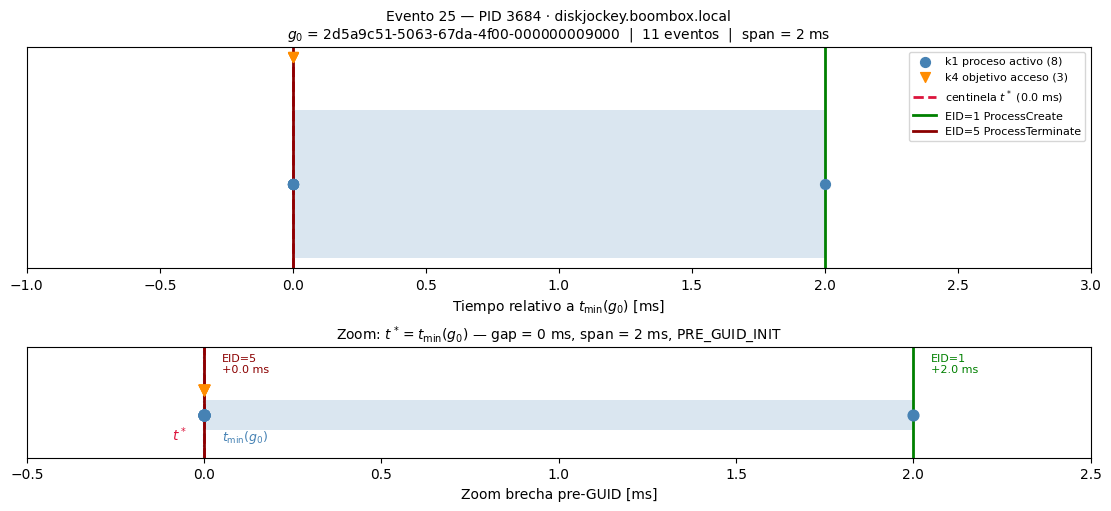

Figura guardada: ../sesion-2/img/ev25_timeline.png


In [355]:
import matplotlib.pyplot as plt

eid1_25s = df[(df["EventID"]==1) & (df["Computer"]==c25) & (df["ProcessId"]==p25)].sort_values("ts")
eid5_25s = df[(df["EventID"]==5) & (df["Computer"]==c25) & (df["ProcessId"]==p25)].sort_values("ts")

origin25  = t_min_25
star25_ms = (t_star25 - origin25).total_seconds() * 1000
max25_ms  = (t_max_25  - origin25).total_seconds() * 1000

colors  = {"k1":"steelblue","k2":"green","k3":"purple","k4":"darkorange"}
labels  = {"k1":"k1 proceso activo","k2":"k2 hijos","k3":"k3 origen acceso","k4":"k4 objetivo acceso"}
markers = {"k1":"o","k2":"s","k3":"^","k4":"v"}
y_off   = {"k1":0,"k2":0.15,"k3":-0.15,"k4":0.3}
ms25    = {k: [(t-origin25).total_seconds()*1000 for t in L_25[L_25["kpair"]==k]["ts"]] for k in ["k1","k2","k3","k4"]}
e1_ms25 = [(t-origin25).total_seconds()*1000 for t in eid1_25s["ts"]]
e5_ms25 = [(t-origin25).total_seconds()*1000 for t in eid5_25s["ts"]]

fig, axes = plt.subplots(2, 1, figsize=(11, 5),
                         gridspec_kw={"height_ratios": [2, 1]},
                         constrained_layout=True)

# Panel superior
ax = axes[0]
ax.barh(0, max(max25_ms, 0.5), left=0, height=0.35, color="steelblue", alpha=0.2)
for k in ["k1","k2","k3","k4"]:
    if ms25[k]:
        ax.scatter(ms25[k], [y_off[k]]*len(ms25[k]),
                   color=colors[k], marker=markers[k], s=50, zorder=3,
                   label=f"{labels[k]} ({len(ms25[k])})")
ax.axvline(star25_ms, color="crimson", lw=2, ls="--", label=f"centinela $t^*$ ({star25_ms:.1f} ms)")
for x in e1_ms25:
    ax.axvline(x, color="green", lw=2, label="EID=1 ProcessCreate" if x == e1_ms25[0] else "_")
for x in e5_ms25:
    ax.axvline(x, color="darkred", lw=2, label="EID=5 ProcessTerminate" if x == e5_ms25[0] else "_")
ax.set_yticks([])
ax.set_xlabel("Tiempo relativo a $t_{\\min}(g_0)$ [ms]")
ax.set_title(
    f"Evento 25 — PID 3684 · diskjockey.boombox.local\n"
    f"$g_0$ = {g0_25}  |  {len(L_25)} eventos  |  span = {max25_ms:.0f} ms",
    fontsize=10)
ax.legend(fontsize=8, loc="upper right")
ax.set_xlim(star25_ms - 1, max25_ms + 1)

# Panel inferior: zoom
ax2 = axes[1]
zoom_lo, zoom_hi = star25_ms - 0.5, min(max25_ms + 0.5, 3)
ax2.barh(0, max(max25_ms, 0.5), left=0, height=0.35, color="steelblue", alpha=0.2)
for k in ["k1","k2","k3","k4"]:
    pts = [x for x in ms25[k] if zoom_lo <= x <= zoom_hi]
    if pts:
        ax2.scatter(pts, [y_off[k]]*len(pts), color=colors[k], marker=markers[k], s=60, zorder=3)
ax2.axvline(star25_ms, color="crimson", lw=2, ls="--")
ax2.axvline(0, color="steelblue", lw=1.5, ls=":")
for x in e1_ms25:
    if zoom_lo <= x <= zoom_hi:
        ax2.axvline(x, color="green", lw=2)
        ax2.text(x + 0.05, 0.5, f"EID=1\n+{x:.1f} ms", ha="left", fontsize=8, color="green")
for x in e5_ms25:
    if zoom_lo <= x <= zoom_hi:
        ax2.axvline(x, color="darkred", lw=2)
        ax2.text(x + 0.05, 0.5, f"EID=5\n+{x:.1f} ms", ha="left", fontsize=8, color="darkred")
ax2.text(star25_ms - 0.05, -0.3, "$t^*$", ha="right", color="crimson", fontsize=10)
ax2.text(0.05, -0.3, "$t_{\\min}(g_0)$", ha="left", color="steelblue", fontsize=9)
ax2.set_xlim(zoom_lo, zoom_hi)
ax2.set_ylim(-0.5, 0.8)
ax2.set_yticks([])
ax2.set_xlabel("Zoom brecha pre-GUID [ms]")
ax2.set_title("Zoom: $t^* = t_{\\min}(g_0)$ — gap = 0 ms, span = 2 ms, PRE_GUID_INIT", fontsize=10)

OUT = "../sesion-2/img/ev25_timeline.png"
fig.savefig(OUT, dpi=150, bbox_inches="tight")
plt.show()
print(f"Figura guardada: {OUT}")

---
### Conclusión — Evento 25: `PRE_GUID_INIT`, gap = 0 ms

`sc.exe` (PID 3684) es el proceso hijo identificado en k2 del evento 24.
Su `ParentProcessGuid` en el EID=1 es $g_0^{(24)}$ — la cadena de ejecución
queda confirmada:

$$
\texttt{cmd.exe}\;(\text{PID 1620})
\;\to\; \texttt{cmd.exe}\;(\text{PID 3088})
\;\to\; \texttt{sc.exe}\;(\text{PID 3684})
\quad [\texttt{sc.exe qc npcap}]
$$

| Aspecto | Valor |
|---------|-------|
| Gap $t^* - t_{\min}(g_0)$ | 0 ms |
| $\lvert\mathcal{L}(g_0)\rvert$ | 11 eventos (k1=8, k4=3) |
| Span | 2 ms |
| Hijos (k2) | $\emptyset$ — `sc.exe` no crea procesos |
| k4 (EID=10) | 3 accesos del sistema (mismo patrón que evento 24) |

$$
t_{\min}(g_0) - \delta \;\leq\; t^* \quad (\delta = 0\,\text{ms})
\;\implies\; \texttt{REPLACE\_GUID} \quad [\texttt{PRE\_GUID\_INIT}]
$$

$g_0 =$ `2d5a9c51-5063-67da-4f00-000000009000` es el GUID correcto.

---
## Caso $\lvert\mathcal{G}\rvert = 1$ — Evento 28

**PID 8404 · `theblock.boombox.local` · fila 59263**  
`C:\Windows\System32\conhost.exe`

Hijo de `sc.exe` (PID 3104, evento 27). Mismo patrón `PRE_GUID_INIT`:
EID=7 auto-carga, gap = 0 ms. Ciclo de vida más amplio que los casos
anteriores: 33 DLLs cargadas tras la asignación de $g_0$ (span = 151 ms).

In [356]:
# Evento centinela e* — evento 28
ev28     = sentinel_k1.iloc[28]
t_star28 = ev28["ts"]
p28      = ev28["ProcessId"]
c28      = ev28["Computer"]

print("=== Evento centinela e* ===")
print(ev28[["_original_row_index","EventID","Computer","ProcessId","Image","ts"]].to_string())
auto28 = str(ev28.get("Image","")).lower() == str(ev28.get("ImageLoaded","")).lower()
print(f"Image == ImageLoaded (auto-carga): {auto28}")

# G(p, c)
G28   = compute_G(df, p28, c28)
g0_28 = list(G28)[0]
print(f"\nG({int(p28)}, {c28}) = {{{g0_28}}}")
print(f"|G| = {len(G28)}")

# L(g0)
k1_28 = df[df["ProcessGuid"]       == g0_28][["ts","EventID","ProcessId","Image","Computer"]].assign(kpair="k1")
k2_28 = df[df["ParentProcessGuid"] == g0_28][["ts","EventID","ProcessId","Image","Computer"]].assign(kpair="k2")
k3_28 = df[df["SourceProcessGUID"] == g0_28][["ts","EventID","ProcessId","Image","Computer"]].assign(kpair="k3") if "SourceProcessGUID" in df.columns else pd.DataFrame()
k4_28 = df[df["TargetProcessGUID"] == g0_28][["ts","EventID","ProcessId","Image","Computer"]].assign(kpair="k4") if "TargetProcessGUID" in df.columns else pd.DataFrame()
L_28  = pd.concat([k1_28, k2_28, k3_28, k4_28]).dropna(subset=["ts"]).sort_values("ts")

print("\nEventos de g0 por k-pair y EID:")
print(L_28.groupby("kpair")["EventID"].value_counts().sort_index())

t_min_28 = L_28["ts"].min()
t_max_28 = L_28["ts"].max()
gap_28   = (t_min_28 - t_star28).total_seconds() * 1000

print(f"\nt_min(g0) = {t_min_28}")
print(f"t*        = {t_star28}")
print(f"t_max(g0) = {t_max_28}")
print(f"gap = {gap_28:.1f} ms  |  span = {(t_max_28-t_min_28).total_seconds()*1000:.0f} ms")

# EID=1: proceso creador
eid1_28 = df[(df["EventID"]==1) & (df["Computer"]==c28) & (df["ProcessId"]==p28)].sort_values("ts")
print("\n=== EID=1 de conhost.exe (PID 8404) ===")
cols_e1 = ["ts","ProcessGuid","ProcessId","Image","ParentProcessGuid","ParentProcessId","ParentImage","CommandLine","User"]
print(eid1_28[[c for c in cols_e1 if c in eid1_28.columns]].to_string(index=False))

=== Evento centinela e* ===
_original_row_index                              59263
EventID                                              7
Computer                        theblock.boombox.local
ProcessId                                       8404.0
Image                  C:\Windows\System32\conhost.exe
ts                          2025-03-19 05:07:59.894000
Image == ImageLoaded (auto-carga): True

G(8404, theblock.boombox.local) = {4a85d404-512f-67da-1501-000000005500}
|G| = 1

Eventos de g0 por k-pair y EID:
kpair  EventID
k1     1           1
       5           1
       7          33
k3     10          1
k4     10          1
Name: count, dtype: int64

t_min(g0) = 2025-03-19 05:07:59.894000
t*        = 2025-03-19 05:07:59.894000
t_max(g0) = 2025-03-19 05:08:00.045000
gap = 0.0 ms  |  span = 151 ms

=== EID=1 de conhost.exe (PID 8404) ===
                     ts                          ProcessGuid  ProcessId                           Image                    ParentProcessGuid  ParentPro

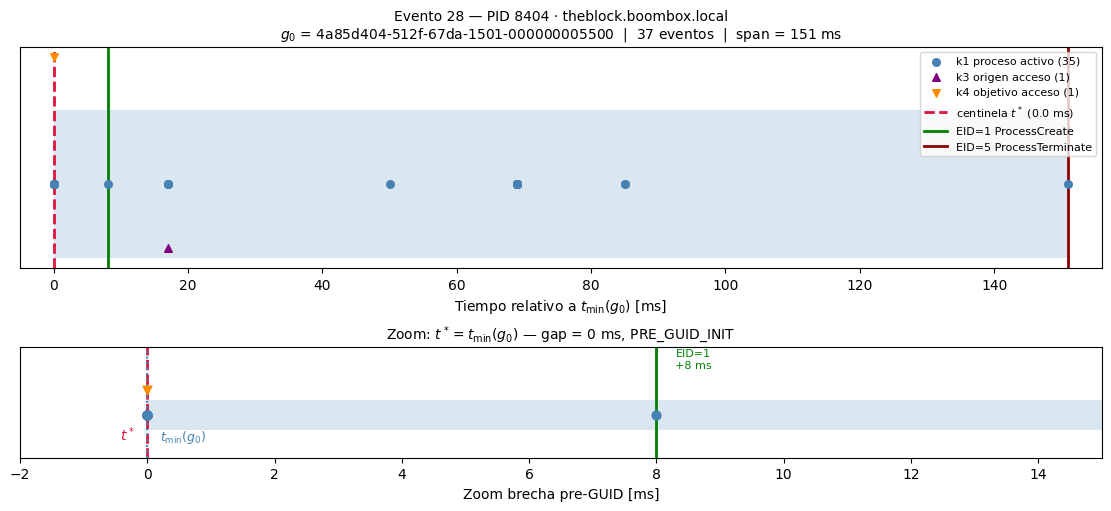

Figura guardada: ../sesion-2/img/ev28_timeline.png


In [357]:
import matplotlib.pyplot as plt

eid1_28s = df[(df["EventID"]==1) & (df["Computer"]==c28) & (df["ProcessId"]==p28)].sort_values("ts")
eid5_28s = df[(df["EventID"]==5) & (df["Computer"]==c28) & (df["ProcessId"]==p28)].sort_values("ts")

origin28  = t_min_28
star28_ms = (t_star28 - origin28).total_seconds() * 1000
max28_ms  = (t_max_28  - origin28).total_seconds() * 1000

colors  = {"k1":"steelblue","k2":"green","k3":"purple","k4":"darkorange"}
labels  = {"k1":"k1 proceso activo","k2":"k2 hijos","k3":"k3 origen acceso","k4":"k4 objetivo acceso"}
markers = {"k1":"o","k2":"s","k3":"^","k4":"v"}
y_off   = {"k1":0,"k2":0.15,"k3":-0.15,"k4":0.3}
ms28 = {k: [(t-origin28).total_seconds()*1000 for t in L_28[L_28["kpair"]==k]["ts"]] for k in ["k1","k2","k3","k4"]}
e1_ms28 = [(t-origin28).total_seconds()*1000 for t in eid1_28s["ts"]]
e5_ms28 = [(t-origin28).total_seconds()*1000 for t in eid5_28s["ts"]]

fig, axes = plt.subplots(2, 1, figsize=(11, 5),
                         gridspec_kw={"height_ratios": [2, 1]},
                         constrained_layout=True)

ax = axes[0]
ax.barh(0, max28_ms, left=0, height=0.35, color="steelblue", alpha=0.2)
for k in ["k1","k2","k3","k4"]:
    if ms28[k]:
        ax.scatter(ms28[k], [y_off[k]]*len(ms28[k]),
                   color=colors[k], marker=markers[k], s=30, zorder=3,
                   label=f"{labels[k]} ({len(ms28[k])})")
ax.axvline(star28_ms, color="crimson", lw=2, ls="--",
           label=f"centinela $t^*$ ({star28_ms:.1f} ms)")
for x in e1_ms28:
    ax.axvline(x, color="green", lw=2,
               label="EID=1 ProcessCreate" if x == e1_ms28[0] else "_")
for x in e5_ms28:
    ax.axvline(x, color="darkred", lw=2,
               label="EID=5 ProcessTerminate" if x == e5_ms28[0] else "_")
ax.set_yticks([])
ax.set_xlabel("Tiempo relativo a $t_{\\min}(g_0)$ [ms]")
ax.set_title(
    f"Evento 28 — PID 8404 · theblock.boombox.local\n"
    f"$g_0$ = {g0_28}  |  {len(L_28)} eventos  |  span = {max28_ms:.0f} ms",
    fontsize=10)
ax.legend(fontsize=8, loc="upper right")
ax.set_xlim(star28_ms - 5, max28_ms + 5)

ax2 = axes[1]
zoom_lo, zoom_hi = star28_ms - 2, 15
ax2.barh(0, max28_ms, left=0, height=0.35, color="steelblue", alpha=0.2)
for k in ["k1","k2","k3","k4"]:
    pts = [x for x in ms28[k] if zoom_lo <= x <= zoom_hi]
    if pts:
        ax2.scatter(pts, [y_off[k]]*len(pts),
                    color=colors[k], marker=markers[k], s=40, zorder=3)
ax2.axvline(star28_ms, color="crimson", lw=2, ls="--")
ax2.axvline(0, color="steelblue", lw=1.5, ls=":")
for x in e1_ms28:
    if zoom_lo <= x <= zoom_hi:
        ax2.axvline(x, color="green", lw=2)
        ax2.text(x+0.3, 0.55, f"EID=1\n+{x:.0f} ms", ha="left", fontsize=8, color="green")
ax2.text(star28_ms - 0.2, -0.3, "$t^*$", ha="right", color="crimson", fontsize=10)
ax2.text(0.2, -0.3, "$t_{\\min}(g_0)$", ha="left", color="steelblue", fontsize=9)
ax2.set_xlim(zoom_lo, zoom_hi)
ax2.set_ylim(-0.5, 0.8)
ax2.set_yticks([])
ax2.set_xlabel("Zoom brecha pre-GUID [ms]")
ax2.set_title("Zoom: $t^* = t_{\\min}(g_0)$ — gap = 0 ms, PRE_GUID_INIT", fontsize=10)

OUT = "../sesion-2/img/ev28_timeline.png"
fig.savefig(OUT, dpi=150, bbox_inches="tight")
plt.show()
print(f"Figura guardada: {OUT}")

---
### Conclusión — Evento 28: `PRE_GUID_INIT`, gap = 0 ms

`conhost.exe` (PID 8404) es lanzado por `sc.exe` (PID 3104, evento 27)
con `CommandLine = conhost.exe 0xffffffff -ForceV1` — inicialización
estándar de consola Windows.

| Aspecto | Valor |
|---------|-------|
| Gap $t^* - t_{\min}(g_0)$ | 0 ms |
| $\lvert\mathcal{L}(g_0)\rvert$ | 37 eventos (k1=35, k3=1, k4=1) |
| EID=7 con $g_0$ asignado | 33 DLLs |
| Span | 151 ms |
| Hijos (k2) | $\emptyset$ |
| Padre | `sc.exe` PID 3104 (evento 27, REVIEW) |

$$
t_{\min}(g_0) - \delta \;\leq\; t^* \quad (\delta = 0\,\text{ms})
\;\implies\; \texttt{REPLACE\_GUID} \quad [\texttt{PRE\_GUID\_INIT}]
$$

$g_0 =$ `4a85d404-512f-67da-1501-000000005500` es el GUID correcto.

---
## Caso $\lvert\mathcal{G}\rvert = 1$ — Evento 30

**PID 10964 · `waterfalls.boombox.local` · fila 207839**  
`<unknown process>` · EID=3 (NetworkConnect)

Primer caso con EventID=3 — mecanismo distinto a `PRE_GUID_INIT`.
El proceso real es `nslookup.exe`, identificado a través de $\mathcal{G}(p,c)$.
El GUID centinela aparece **dentro** del ciclo de vida de $g_0$, no antes.

In [358]:
# Evento centinela e* — evento 30
ev30     = sentinel_k1.iloc[30]
t_star30 = ev30["ts"]
p30      = ev30["ProcessId"]
c30      = ev30["Computer"]

print("=== Evento centinela e* ===")
cols_sent = ["_original_row_index","EventID","Computer","ProcessId",
             "Image","ts","Protocol","SourceIp","SourcePort",
             "DestinationIp","DestinationPort","DestinationPortName"]
print(ev30[[c for c in cols_sent if c in ev30.index and pd.notna(ev30[c])]].to_string())

# G(p, c)
G30   = compute_G(df, p30, c30)
g0_30 = list(G30)[0]
print(f"\nG({int(p30)}, {c30}) = {{{g0_30}}}")
print(f"|G| = {len(G30)}  ->  proceso real identificado por G(p,c)")

# Todos los EID=3 para este PID: centinela + evento con GUID real
eid3_all = df[(df["EventID"]==3) & (df["Computer"]==c30) & (df["ProcessId"]==p30)].sort_values("ts")
print(f"\n=== Todos los EID=3 para PID {int(p30)} en {c30} ===")
cols3 = ["_original_row_index","ts","ProcessGuid","Image","Protocol",
         "SourcePort","DestinationIp","DestinationPort"]
print(eid3_all[[c for c in cols3 if c in eid3_all.columns]].to_string(index=False))

=== Evento centinela e* ===
_original_row_index                        207839
EventID                                         3
Computer                 waterfalls.boombox.local
ProcessId                                 10964.0
Image                           <unknown process>
ts                     2025-03-19 05:38:23.382000
Protocol                                      udp
SourceIp                                 10.1.0.6
SourcePort                                62781.0
DestinationIp                            10.1.0.4
DestinationPort                              53.0
DestinationPortName                        domain

G(10964, waterfalls.boombox.local) = {3fc4fefd-584f-67da-9b01-000000004800}
|G| = 1  ->  proceso real identificado por G(p,c)

=== Todos los EID=3 para PID 10964 en waterfalls.boombox.local ===
 _original_row_index                      ts                          ProcessGuid                            Image Protocol  SourcePort DestinationIp  DestinationPort
          

In [359]:
# L(g0): ciclo de vida completo de g0_30
k1_30 = df[df["ProcessGuid"]       == g0_30][["ts","EventID","Image","ProcessGuid"]].assign(kpair="k1")
k2_30 = df[df["ParentProcessGuid"] == g0_30][["ts","EventID","Image","ProcessGuid"]].assign(kpair="k2")
k3_30 = df[df["SourceProcessGUID"] == g0_30][["ts","EventID","Image","ProcessGuid"]].assign(kpair="k3") if "SourceProcessGUID" in df.columns else pd.DataFrame()
k4_30 = df[df["TargetProcessGUID"] == g0_30][["ts","EventID","Image","ProcessGuid"]].assign(kpair="k4") if "TargetProcessGUID" in df.columns else pd.DataFrame()
L_30  = pd.concat([k1_30, k2_30, k3_30, k4_30]).dropna(subset=["ts"]).sort_values("ts")

print("Eventos de g0 por k-pair y EID:")
print(L_30.groupby("kpair")["EventID"].value_counts().sort_index())

t_min_30 = L_30["ts"].min()
t_max_30 = L_30["ts"].max()

print(f"\nt_min(g0) = {t_min_30}")
print(f"t*        = {t_star30}   <-- centinela EID=3 con GUID null")
print(f"t_max(g0) = {t_max_30}")
print(f"\nt_min <= t* <= t_max : {t_min_30 <= t_star30 <= t_max_30}")
print(f"t* - t_min = {(t_star30 - t_min_30).total_seconds()*1000:.0f} ms")
print(f"t_max - t* = {(t_max_30 - t_star30).total_seconds()*1000:.0f} ms")

# EID=5 concurrente con t*?
eid5_30 = df[(df["EventID"]==5) & (df["Computer"]==c30) & (df["ProcessId"]==p30)]
print(f"\nEID=5 (ProcessTerminate) para PID {int(p30)}:")
print(eid5_30[["ts","ProcessGuid","Image"]].to_string(index=False))
concurrente = eid5_30["ts"].iloc[0] == t_star30 if len(eid5_30) else False
print(f"EID=5 timestamp == t* : {concurrente}  <-- race condition con terminacion")

# Tabla completa de L(g0)
print()
display(L_30.reset_index(drop=True))

Eventos de g0 por k-pair y EID:
kpair  EventID
k1     1           1
       3           1
       5           1
       7          11
k4     10          3
Name: count, dtype: int64

t_min(g0) = 2025-03-19 05:38:23.372000
t*        = 2025-03-19 05:38:23.382000   <-- centinela EID=3 con GUID null
t_max(g0) = 2025-03-19 05:38:23.382000

t_min <= t* <= t_max : True
t* - t_min = 10 ms
t_max - t* = 0 ms

EID=5 (ProcessTerminate) para PID 10964:
                     ts                          ProcessGuid                            Image
2025-03-19 05:38:23.382 3fc4fefd-584f-67da-9b01-000000004800 C:\Windows\System32\nslookup.exe
EID=5 timestamp == t* : True  <-- race condition con terminacion



,ts,EventID,Image,ProcessGuid,kpair
0,2025-03-19 05:38:23.372,1,C:\Windows\System32\nslookup.exe,3fc4fefd-584f-67da-9b01-000000004800,k1
1,2025-03-19 05:38:23.375,7,C:\Windows\System32\nslookup.exe,3fc4fefd-584f-67da-9b01-000000004800,k1
2,2025-03-19 05:38:23.375,7,C:\Windows\System32\nslookup.exe,3fc4fefd-584f-67da-9b01-000000004800,k1
3,2025-03-19 05:38:23.375,10,NaN,NaN,k4
4,2025-03-19 05:38:23.375,10,NaN,NaN,k4
5,2025-03-19 05:38:23.376,7,C:\Windows\System32\nslookup.exe,3fc4fefd-584f-67da-9b01-000000004800,k1
6,2025-03-19 05:38:23.376,7,C:\Windows\System32\nslookup.exe,3fc4fefd-584f-67da-9b01-000000004800,k1
7,2025-03-19 05:38:23.377,10,NaN,NaN,k4
8,2025-03-19 05:38:23.377,7,C:\Windows\System32\nslookup.exe,3fc4fefd-584f-67da-9b01-000000004800,k1
9,2025-03-19 05:38:23.378,7,C:\Windows\System32\nslookup.exe,3fc4fefd-584f-67da-9b01-000000004800,k1


In [360]:
# EID=1 de nslookup.exe (PID 10964): proceso creador y contexto de ejecucion
eid1_30 = df[(df["EventID"]==1) & (df["Computer"]==c30) & (df["ProcessId"]==p30)].sort_values("ts")

print("=== EID=1 de nslookup.exe (PID 10964) ===")
cols_e1 = ["ts","ProcessGuid","ProcessId","Image",
           "ParentProcessGuid","ParentProcessId","ParentImage",
           "CommandLine","User"]
print(eid1_30[[c for c in cols_e1 if c in eid1_30.columns]].to_string(index=False))

# Nota: los dos EID=3 tienen SourcePorts distintos (62780 y 62781),
# lo que indica dos conexiones UDP separadas, no dos paquetes de una misma conexion.
# Sysmon EID=3 registra eventos de conexion (connect/sendto), no paquetes individuales.
print()
print("=== Dos conexiones EID=3 de PID 10964 ===")
eid3_30 = df[(df["EventID"]==3) & (df["Computer"]==c30) & (df["ProcessId"]==p30)].sort_values("ts")
cols3 = ["_original_row_index","ts","ProcessGuid","Image","SourcePort","DestinationIp","DestinationPort"]
print(eid3_30[[c for c in cols3 if c in eid3_30.columns]].to_string(index=False))
print()
print("Nota: SourcePort distinto en cada evento -> dos sockets UDP distintos.")
print("Sysmon EID=3 registra conexiones, no paquetes individuales.")

=== EID=1 de nslookup.exe (PID 10964) ===
                     ts                          ProcessGuid  ProcessId                            Image                    ParentProcessGuid  ParentProcessId                                                               ParentImage                                                                   CommandLine                User
2025-03-19 05:38:23.372 3fc4fefd-584f-67da-9b01-000000004800    10964.0 C:\Windows\System32\nslookup.exe 3fc4fefd-508c-67da-8100-000000004800           6872.0 C:\Program Files\Microsoft\Exchange Server\V15\Bin\MSExchangeHMWorker.exe "C:\Windows\system32\nslookup.exe" -type=A WATERFALLS.boombox.local. 10.1.0.4 NT AUTHORITY\SYSTEM

=== Dos conexiones EID=3 de PID 10964 ===
 _original_row_index                      ts                          ProcessGuid                            Image  SourcePort DestinationIp  DestinationPort
              207838 2025-03-19 05:38:23.381 3fc4fefd-584f-67da-9b01-000000004800 C:\Windows\Sy

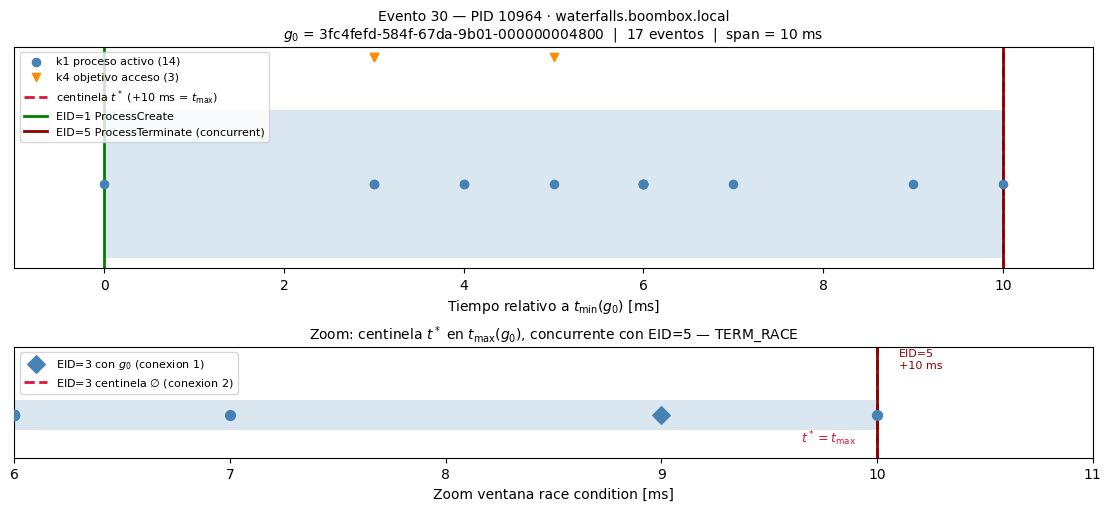

Figura guardada: ../sesion-2/img/ev30_timeline.png


In [361]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

eid1_30s = df[(df["EventID"]==1) & (df["Computer"]==c30) & (df["ProcessId"]==p30)].sort_values("ts")
eid5_30s = df[(df["EventID"]==5) & (df["Computer"]==c30) & (df["ProcessId"]==p30)].sort_values("ts")

origin30  = t_min_30
star30_ms = (t_star30 - origin30).total_seconds() * 1000   # t* relativo a t_min
max30_ms  = (t_max_30  - origin30).total_seconds() * 1000

colors  = {"k1":"steelblue","k4":"darkorange"}
labels  = {"k1":"k1 proceso activo","k4":"k4 objetivo acceso"}
markers_d = {"k1":"o","k4":"v"}
y_off   = {"k1":0,"k4":0.3}
ms30 = {k: [(t-origin30).total_seconds()*1000 for t in L_30[L_30["kpair"]==k]["ts"]]
        for k in ["k1","k4"]}
e1_ms30 = [(t-origin30).total_seconds()*1000 for t in eid1_30s["ts"]]
e5_ms30 = [(t-origin30).total_seconds()*1000 for t in eid5_30s["ts"]]

fig, axes = plt.subplots(2, 1, figsize=(11, 5),
                         gridspec_kw={"height_ratios": [2, 1]},
                         constrained_layout=True)

# ── Panel superior: ciclo de vida completo ───────────────────────────────────
ax = axes[0]
ax.barh(0, max30_ms, left=0, height=0.35, color="steelblue", alpha=0.2)
for k in ["k1","k4"]:
    if ms30[k]:
        ax.scatter(ms30[k], [y_off[k]]*len(ms30[k]),
                   color=colors[k], marker=markers_d[k], s=35, zorder=3,
                   label=f"{labels[k]} ({len(ms30[k])})")
ax.axvline(star30_ms, color="crimson", lw=2, ls="--",
           label=f"centinela $t^*$ (+{star30_ms:.0f} ms = $t_{{\\max}}$)")
for x in e1_ms30:
    ax.axvline(x, color="green", lw=2,
               label="EID=1 ProcessCreate" if x == e1_ms30[0] else "_")
for x in e5_ms30:
    ax.axvline(x, color="darkred", lw=2,
               label="EID=5 ProcessTerminate (concurrent)" if x == e5_ms30[0] else "_")
ax.set_yticks([])
ax.set_xlabel("Tiempo relativo a $t_{\\min}(g_0)$ [ms]")
ax.set_title(
    f"Evento 30 — PID 10964 · waterfalls.boombox.local\n"
    f"$g_0$ = {g0_30}  |  {len(L_30)} eventos  |  span = {max30_ms:.0f} ms",
    fontsize=10)
ax.legend(fontsize=8, loc="upper left")
ax.set_xlim(-1, max30_ms + 1)

# ── Panel inferior: zoom en la ventana de race condition (t_max) ────────────
ax2 = axes[1]
zoom_lo, zoom_hi = max30_ms - 4, max30_ms + 1
ax2.barh(0, max30_ms, left=0, height=0.35, color="steelblue", alpha=0.2)
for k in ["k1","k4"]:
    pts = [x for x in ms30[k] if zoom_lo <= x <= zoom_hi]
    if pts:
        ax2.scatter(pts, [y_off[k]]*len(pts),
                    color=colors[k], marker=markers_d[k], s=50, zorder=3)
# EID=3 con GUID real (conexion previa)
eid3_real_ms = [(t-origin30).total_seconds()*1000
                for t in df[(df["ProcessGuid"]==g0_30) & (df["EventID"]==3)
                           & (df["Computer"]==c30)]["ts"]]
if eid3_real_ms:
    ax2.scatter(eid3_real_ms, [0]*len(eid3_real_ms),
                color="steelblue", marker="D", s=80, zorder=4,
                label="EID=3 con $g_0$ (conexion 1)")
# Centinela
ax2.axvline(star30_ms, color="crimson", lw=2, ls="--",
            label="EID=3 centinela $\\emptyset$ (conexion 2)")
# EID=5 concurrente
for x in e5_ms30:
    if zoom_lo <= x <= zoom_hi:
        ax2.axvline(x, color="darkred", lw=2)
        ax2.text(x + 0.1, 0.55, f"EID=5\n+{x:.0f} ms", ha="left", fontsize=8, color="darkred")
ax2.text(star30_ms - 0.1, -0.32, "$t^* = t_{\\max}$", ha="right",
         color="crimson", fontsize=9)
ax2.set_xlim(zoom_lo, zoom_hi)
ax2.set_ylim(-0.5, 0.8)
ax2.set_yticks([])
ax2.set_xlabel("Zoom ventana race condition [ms]")
ax2.set_title(
    "Zoom: centinela $t^*$ en $t_{\\max}(g_0)$, concurrente con EID=5 — TERM_RACE",
    fontsize=10)
ax2.legend(fontsize=8, loc="upper left")

OUT = "../sesion-2/img/ev30_timeline.png"
fig.savefig(OUT, dpi=150, bbox_inches="tight")
plt.show()
print(f"Figura guardada: {OUT}")

### Conclusión — Evento 30

**Mecanismo: POST_GUID_TERMINATE**

A diferencia de los casos anteriores (PRE_GUID_INIT), el evento centinela de
``nslookup.exe`` (PID 10964) se produce *al final* del ciclo de vida del proceso,
no al principio:

- t\* = t_max(g0) — el evento centinela coincide cronológicamente con EID=5
  (ProcessTerminate), mientras que el EID=1 está en t_min(g0).
- Verificación temporal: t_min(g0) ≤ t\* ≤ t_max(g0) → **REPLACE_GUID [POST_GUID_TERMINATE]** con g0.
-  es el *iniciador* de las conexiones UDP (IP origen 10.1.0.6 = waterfalls):
  los dos EID=3 son consecuencia directa del proceso haciendo sus consultas DNS,
  no eventos atrapados por azar. El GUID se pierde en el segundo socket porque
  el contexto del proceso ya se estaba liberando.

**Robustez de la recuperación:**

g0 ∈ G(p,c) proviene principalmente de k1 (EID=1, EID=7, EID=5).
El primer EID=3 con g0 (fila 207838) es redundante para la recuperación:
incluso sin él, |G| = 1 y el algoritmo asigna g0 al centinela.
La condición |G| = 1 garantiza la recuperación independientemente
de qué k-pairs específicos contribuyen al conjunto.

**Contraste con PRE_GUID_INIT:**

| Mecanismo | Posición de t\* | Contexto del driver |
|-----------|----------------|---------------------|
| PRE_GUID_INIT | t\* < t_min(g0) | Driver carga imagen antes de asignar GUID |
| POST_GUID_TERMINATE | t\* ≈ t_max(g0) | Driver de red registra conexión durante limpieza |

**Acción: `REPLACE_GUID [POST_GUID_TERMINATE]`** — g0 es el GUID correcto para el evento centinela.